In [20]:
import pdb
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pylab as pylab
import cartopy
import cartopy.crs as ccrs
import pickle as pkl
import glob
from metpy import calc
from metpy.units import units
import matplotlib.patches as patches
from scipy import stats
import pandas as pd
from endgame import hist2d

pylab.rcParams['figure.figsize'] = (50., 50.)
%matplotlib inline

In [19]:
cd ../..

/home/users/cornkle/pythonWorkspace/proj_CEH


In [9]:
table_test = '/gws/nopw/j04/lmcs/cklein/CP_models/MCS_files/WAf/CP4_MCS_table_runOnJasmin/MCS_table_JASMIN_5000km2_-50C_15W20E7-20N_1998-2007_17h.csv'
test = pd.read_csv(table_test)

In [10]:
list(test.keys())

['Unnamed: 0',
 'date',
 'month',
 'hour',
 'minute',
 'year',
 'day',
 'area',
 '60area',
 '65area',
 '70area',
 '75area',
 'tmin',
 'minlon',
 'minlat',
 'maxlon',
 'maxlat',
 'clon',
 'clat',
 'tminlon',
 'tminlat',
 'tmean',
 'tp1',
 'stormID']

In [1]:
def equal_tables(long, short):
    # Columns that must match to determine common entries
    key_columns = ['indy', 'indx', 'index', 'hour', 'day', 'year']

    # Keep only rows in df_long that have a match in df_short based on key_columns
    long = long.merge(short[key_columns], on=key_columns, how='inner')
    return long

In [65]:
table_path = "/gws/nopw/j04/lmcs/cklein/CP_models/MCS_files/WAf/CP4_box_JASMIN/mean3h_v2/tables/"

In [66]:
lhist_tab = pd.read_csv(table_path+'hist_mean_table_JASMIN_3hmeansVersion.csv', index_col=0, low_memory=False).transpose()
lfut_tab =  pd.read_csv(table_path+'fut_mean_table_JASMIN_3hmeansVersion.csv', index_col=0,low_memory=False).transpose()

In [67]:
lahist_tab = pd.read_csv(table_path+'hist_anom_table_JASMIN_3hmeansVersion.csv', index_col=0, low_memory=False).transpose()
lafut_tab =  pd.read_csv(table_path+'fut_anom_table_JASMIN_3hmeansVersion.csv', index_col=0, low_memory=False).transpose()

In [68]:
for dat in [lhist_tab,lfut_tab,lahist_tab,lafut_tab]:
    for var in dat.keys():
        try:
            dat[var] = dat[var].astype(float)
        except:
            pass

In [69]:
lahist = lahist_tab.copy()
lafut = lafut_tab.copy()

lhist = lhist_tab.copy()
lfut_long = lfut_tab.copy()

In [70]:
print(lahist['sh_1deg'].size)
print(lafut['sh_1deg'].size)
print(lhist['sh_1deg'].size)
print(lfut_long['sh_1deg'].size)

28717
19899
28717
20132


In [71]:
numeric_cols_h1 = lhist.select_dtypes(include=[np.number]).columns
numeric_cols_h2 = lahist.select_dtypes(include=[np.number]).columns

numeric_cols_f1 = lfut_long.select_dtypes(include=[np.number]).columns
numeric_cols_f2 = lafut.select_dtypes(include=[np.number]).columns

common_numhist = numeric_cols_h1.intersection(numeric_cols_h2)
common_numfut = numeric_cols_f1.intersection(numeric_cols_f2)

In [72]:
lfut = equal_tables(lfut_long, lafut)

In [73]:
print(lahist['sh_1deg'].size)
print(lafut['sh_1deg'].size)
print(lhist['sh_1deg'].size)
print(lfut['sh_1deg'].size)

28717
19899
28717
19899


In [74]:
lhist2 = pd.read_csv('/gws/nopw/j04/lmcs/cklein/CP_models/MCS_files/WAf/moved_fromCEH/tables/hist_table_1700_inclStormChar.csv', index_col=0).transpose()
lfut2 =  pd.read_csv('/gws/nopw/j04/lmcs/cklein/CP_models/MCS_files/WAf/moved_fromCEH/tables/fut_table_1700_inclStormChar.csv', index_col=0).transpose()

In [75]:
lhist['area'].min()

258.0

In [76]:
print(list(lhist.keys()))

['tcwv_0.25deg', 'sh_0.25deg', 'lh_0.25deg', 't2_0.25deg', 'q2_0.25deg', 'pblH_0.25deg', 'shear_0.25deg', 'u_mid_0.25deg', 'u_srfc_0.25deg', 'v_mid_0.25deg', 'v_srfc_0.25deg', 'q_mid_0.25deg', 't_mid_0.25deg', 't_srfc_0.25deg', 'q_srfc_0.25deg', 'geoH_srfc_0.25deg', 'lsRain_noon_0.25deg', 'lwout_noon_0.25deg', 'SM_0.25deg', 'lw_net_0.25deg', 'sw_in_0.25deg', 'sw_net_0.25deg', 'u10_0.25deg', 'v10_0.25deg', 'tcwv_1deg', 'sh_1deg', 'lh_1deg', 't2_1deg', 'q2_1deg', 'pblH_1deg', 'shear_1deg', 'u_mid_1deg', 'u_srfc_1deg', 'v_mid_1deg', 'v_srfc_1deg', 'q_mid_1deg', 't_mid_1deg', 't_srfc_1deg', 'q_srfc_1deg', 'geoH_srfc_1deg', 'lsRain_noon_1deg', 'lwout_noon_1deg', 'SM_1deg', 'lw_net_1deg', 'sw_in_1deg', 'sw_net_1deg', 'u10_1deg', 'v10_1deg', 'tcwv_2deg', 'sh_2deg', 'lh_2deg', 't2_2deg', 'q2_2deg', 'pblH_2deg', 'shear_2deg', 'u_mid_2deg', 'u_srfc_2deg', 'v_mid_2deg', 'v_srfc_2deg', 'q_mid_2deg', 't_mid_2deg', 't_srfc_2deg', 'q_srfc_2deg', 'geoH_srfc_2deg', 'lsRain_noon_2deg', 'lwout_noon_2deg'

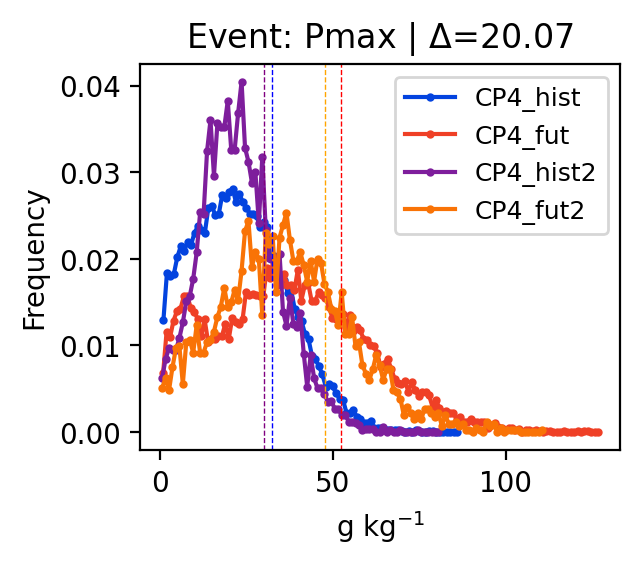

In [77]:
f = plt.figure(figsize=(9,5), dpi=200)
ax = f.add_subplot(236)

var = 'pmax'
cp4 = hist2d.basic_1d_binning(lhist[var], np.arange(np.min(lhist[var]), np.max(lhist[var]),1))
cp4f = hist2d.basic_1d_binning(lfut[var], np.arange(np.min(lfut[var]), np.max(lfut[var]),1))

cp42 = hist2d.basic_1d_binning(lhist2[var], np.arange(np.min(lhist2[var]), np.max(lhist2[var]),1))
cp4f2 = hist2d.basic_1d_binning(lfut2[var], np.arange(np.min(lfut2[var]), np.max(lfut2[var]),1))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.plot(cp42['xbins'], cp42['nb']/np.sum(cp42['nb']), color='xkcd:purple', label='CP4_hist2', marker='o', markersize=2)
plt.plot(cp4f2['xbins'], cp4f2['nb']/np.sum(cp4f2['nb']), color='xkcd:orange', label='CP4_fut2', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('g kg$^{-1}$')
plt.title('Event: Pmax | $\Delta$='+str(np.round(np.nanpercentile(lfut[var],75)-np.nanpercentile(lhist[var],75),2)))
ax.axvline(np.nanpercentile(lhist[var],75), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanpercentile(lfut[var],75), color='r', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanpercentile(lhist2[var],75), color='purple', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanpercentile(lfut2[var],75), color='orange', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)
plt.tight_layout()

In [78]:
def datcheck():

    for dat in [lfut, lhist, lafut, lahist]:
        dat.index = dat.index.astype(int)
        dat = dat.reset_index(drop=True)

    print('Fut similarity')
    print(lafut.shape, lfut.shape)  # Should be the same
    print((lafut.index == lfut.index).all())  # Should be True
    print('Hist similarity')
    print(lahist.shape, lhist.shape)  # Should be the same
    print((lahist.index == lhist.index).all())  # Should be True

In [79]:
datcheck()

Fut similarity
(19899, 128) (19899, 128)
True
Hist similarity
(28717, 132) (28717, 132)
True


In [80]:
lahist['EF'] = (lahist['lh_cl'] / (lahist['lh_cl']+lahist['sh_cl']))
lafut['EF'] = (lafut['lh_cl'] / (lafut['lh_cl']+lafut['sh_cl']))

In [81]:
lhist['EF'] = (lhist['lh_1deg'] / (lhist['lh_1deg']+lhist['sh_1deg']))
lfut['EF'] = (lfut['lh_1deg'] / (lfut['lh_1deg']+lfut['sh_1deg']))

In [82]:
lhist['Tdiff'] = (lhist['t2_1deg']-273.15) - lhist['t_srfc_1deg']
lfut['Tdiff'] = (lfut['t2_1deg']-273.15) - lfut['t_srfc_1deg']

In [83]:
lahist['Tdiff'] = (lahist['t2_1deg']-273.15) - lahist['t_srfc_1deg']
lafut['Tdiff'] = (lafut['t2_1deg']-273.15) - lafut['t_srfc_1deg']

In [84]:
import metpy
def calc_theta_table(da, moist=False):    
    # p = 1000

    # t = da['t2_1deg'].values - 273.15
    # q = da['q2_1deg'].values
    
    # if moist:
    #     theta = u_met.theta_e(p, t, q)
    # else:
    #     theta = u_met.theta(p,t) 
        
        
    # p = 925
    
    # t = da['t_srfc_1deg'].values
    # q = da['q_srfc_1deg'].values/1000
    
    # if moist:
    #     theta2 = u_met.theta_e(p, t, q)
    # else:
    #     theta2 = u_met.theta(p,t) 

    p = units.Quantity(925, 'hPa')
    t = units.Quantity(da['t_srfc_1deg'].values, 'K')
    q = units.Quantity(da['q_srfc_1deg'].values, 'kg/kg')
    
    # p_up = units.Quantity(650, 'hPa')
    # t_up = units.Quantity(da['t_mid'].values+273.15, 'K')
    
    # thetaes_up = np.array(calc.saturation_equivalent_potential_temperature(p_up,t_up))
    
    dew = calc.dewpoint_from_specific_humidity(p,t,q)
    thetae_down = np.array(calc.equivalent_potential_temperature(p,t,dew))
     
    thetae = thetae_down #-thetaes_up 

    theta = np.array(calc.potential_temperature(p,t))

    if moist:
        theta_out = thetae
    else:
        theta_out = theta
    
    
    return np.array(theta_out)

In [85]:
def calc_rh_table(da):

    p = units.Quantity(925, 'hPa')
    t = units.Quantity(da['t_srfc_1deg'].values, 'K')
    q = units.Quantity(da['q_srfc_1deg'].values, 'kg/kg')

    dew = calc.dewpoint_from_specific_humidity(p,t,q)
    rh = calc.relative_humidity_from_dewpoint(t, dew)

    return np.array(rh)

In [86]:
print(lafut.shape)
print(lfut.shape)
print((lafut[common_numfut]+lfut[common_numfut]).shape)

(19899, 130)
(19899, 130)
(19899, 122)


In [87]:
lhist_thetae = calc_theta_table(lhist, moist=True)
lhist_theta = calc_theta_table(lhist)

lfut_thetae = calc_theta_table(lfut, moist=True)
lfut_theta = calc_theta_table(lfut)

In [88]:
lahist_thetae = calc_theta_table(lahist[common_numhist]+lhist[common_numhist], moist=True)
lahist_theta = calc_theta_table(lahist[common_numhist]+lhist[common_numhist])

lafut_thetae = calc_theta_table(lafut[common_numfut]+lfut[common_numfut], moist=True)
lafut_theta = calc_theta_table(lafut[common_numfut]+lfut[common_numfut])

In [89]:
lahist_thetae = lahist_thetae - lhist_thetae
lafut_thetae = lafut_thetae - lfut_thetae

lahist_theta = lahist_theta - lhist_theta
lafut_theta = lafut_theta - lfut_theta

In [90]:
lahist['theta-e'] = lahist_thetae
lafut['theta-e'] = lafut_thetae

lahist['theta'] = lahist_theta
lafut['theta'] = lafut_theta

In [91]:
lhist['theta-e'] = lhist_thetae
lfut['theta-e'] = lfut_thetae

lhist['theta'] = lhist_theta
lfut['theta'] = lfut_theta

In [92]:
lhist['rh'] = calc_rh_table(lhist)
lfut['rh'] = calc_rh_table(lfut)

In [93]:
efrain_mask_fut = (lfut['EF']<0.7) & (lfut['pmax']>0.1) & (lfut['hour']<=18)  
efrain_mask_hist = (lhist['EF']<0.7) & (lhist['pmax']>0.1) & (lhist['hour']<=18) 

In [94]:
from endgame import hist2d

In [95]:
lhist['pmax'].max()

86.98398495612032

In [96]:
lfut['pmax'].max()

127.97294944874506

In [97]:
lhist = lhist[efrain_mask_hist]
lfut = lfut[efrain_mask_fut]
lahist = lahist[efrain_mask_hist]
lafut = lafut[efrain_mask_fut]

In [98]:
datcheck()

Fut similarity
(9778, 132) (9778, 132)
True
Hist similarity
(11026, 136) (11026, 136)
True


In [99]:
np.unique(lahist.hour)

array([17., 18.])

In [53]:
lahist.hour

0        17.0
6        17.0
8        17.0
9        17.0
13       18.0
         ... 
28710    17.0
28711    17.0
28713    17.0
28714    17.0
28716    18.0
Name: hour, Length: 11026, dtype: float64

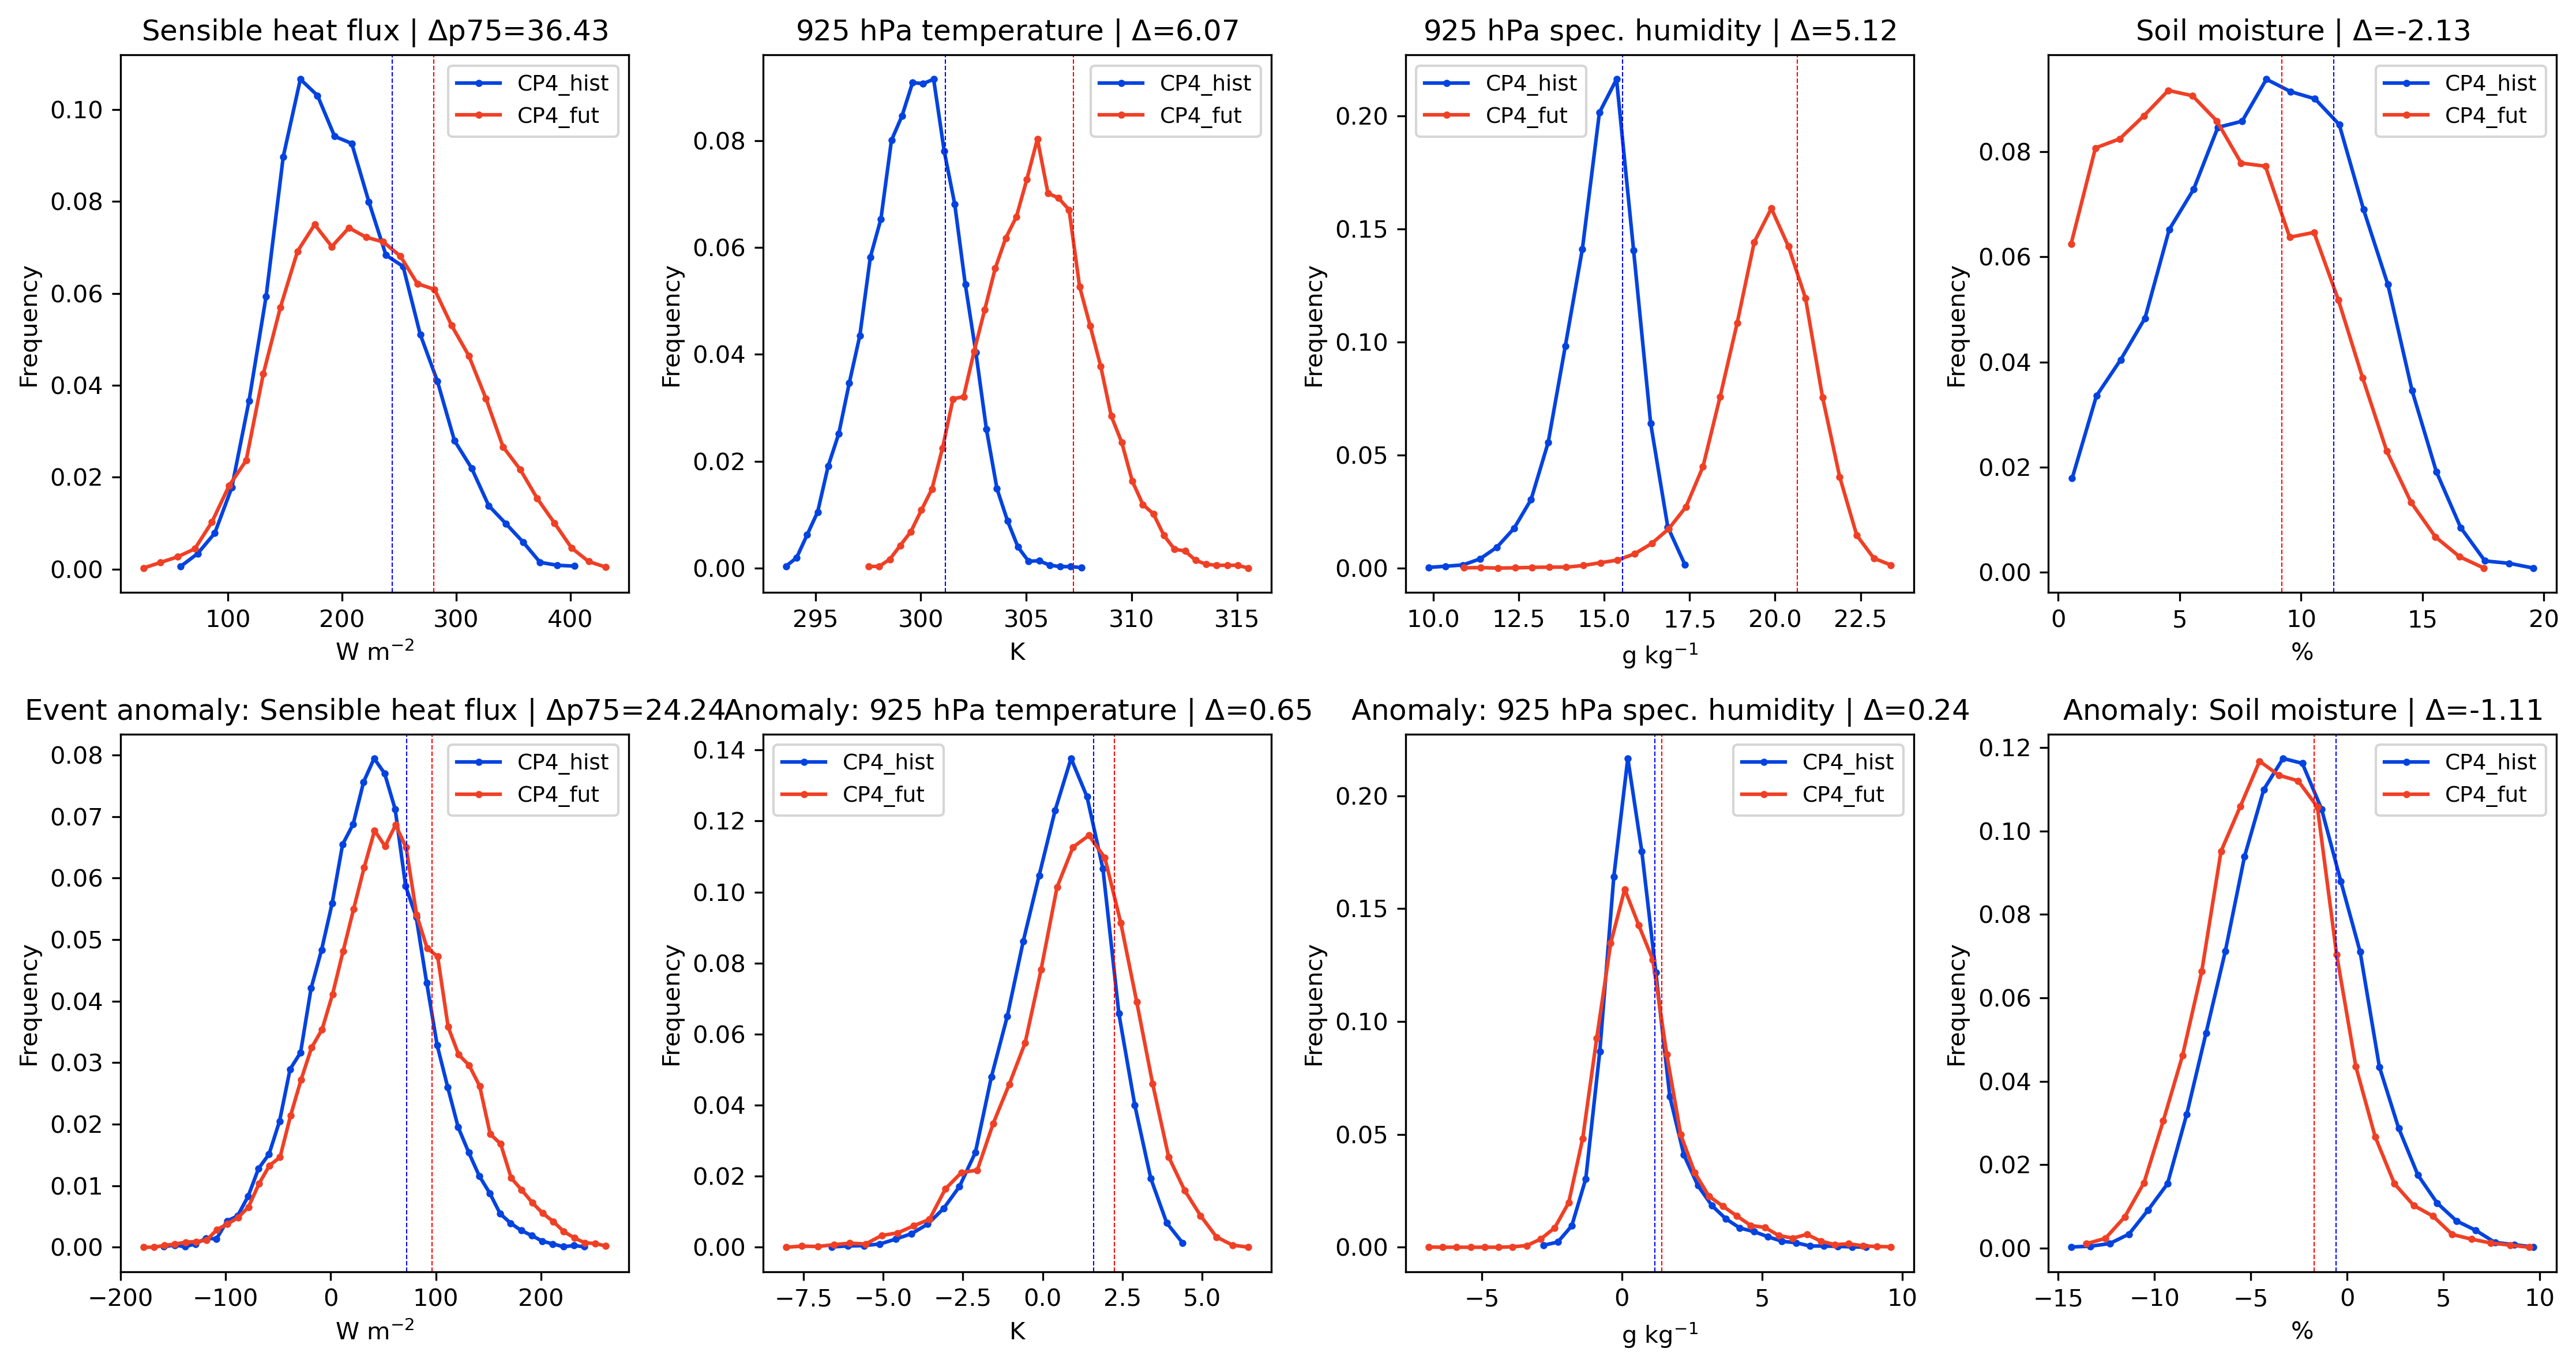

In [54]:
f = plt.figure(figsize=(15,8), dpi=300)



ax = f.add_subplot(241)

var = 'sh_1deg'
efplot = lhist[var]
efhist = efplot
efplot = lfut[var]
effut = efplot
cp4 = hist2d.basic_1d_binning(efhist, np.arange(np.min(efhist), np.max(efhist),15))
cp4f = hist2d.basic_1d_binning(effut, np.arange(np.min(effut), np.max(effut),15))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('W m$^{-2}$')
plt.title('Sensible heat flux | $\Delta$p75='+str(np.round(np.nanpercentile(effut,75)-np.nanpercentile(efhist,75),2)))
ax.axvline(np.nanpercentile(efhist,75), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanpercentile(effut,75), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)


ax = f.add_subplot(242)

var = 't_srfc_1deg'
cp4 = hist2d.basic_1d_binning(lhist[var], np.arange(np.min(lhist[var]), np.max(lhist[var]),0.5))
cp4f = hist2d.basic_1d_binning(lfut[var], np.arange(np.min(lfut[var]), np.max(lfut[var]),0.5))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('K')
plt.title('925 hPa temperature | $\Delta$='+str(np.round(np.nanpercentile(lfut[var],75)-np.nanpercentile(lhist[var],75),2)))
ax.axvline(np.nanpercentile(lhist[var],75), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanpercentile(lfut[var],75), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)


ax = f.add_subplot(243)

var = 'q_srfc_1deg'
cp4 = hist2d.basic_1d_binning(lhist[var]*1000, np.arange(np.min(lhist[var]*1000), np.max(lhist[var]*1000),0.5))
cp4f = hist2d.basic_1d_binning(lfut[var]*1000, np.arange(np.min(lfut[var]*1000), np.max(lfut[var]*1000),0.5))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('g kg$^{-1}$')
plt.title('925 hPa spec. humidity | $\Delta$='+str(np.round(np.nanpercentile(lfut[var]*1000,75)-np.nanpercentile(lhist[var]*1000,75),2)))
ax.axvline(np.nanpercentile(lhist[var]*1000,75), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanpercentile(lfut[var]*1000,75), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)

ax = f.add_subplot(244)

var = 'SM_1deg'
cp4 = hist2d.basic_1d_binning(lhist[var], np.arange(np.min(lhist[var]), np.max(lhist[var]),1))
cp4f = hist2d.basic_1d_binning(lfut[var], np.arange(np.min(lfut[var]), np.max(lfut[var]),1))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('%')
plt.title('Soil moisture | $\Delta$='+str(np.round(np.nanpercentile(lfut[var],75)-np.nanpercentile(lhist[var],75),2)))
ax.axvline(np.nanpercentile(lhist[var],75), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanpercentile(lfut[var],75), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)



ax = f.add_subplot(245)

var = 'sh_1deg'
efplot = lahist[var]
efhist = efplot
efplot = lafut[var]
effut = efplot
cp4 = hist2d.basic_1d_binning(efhist, np.arange(np.min(efhist), np.max(efhist),10))
cp4f = hist2d.basic_1d_binning(effut, np.arange(np.min(effut), np.max(effut),10))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('W m$^{-2}$')
plt.title('Event anomaly: Sensible heat flux | $\Delta$p75='+str(np.round(np.nanpercentile(effut,75)-np.nanpercentile(efhist,75),2)))
ax.axvline(np.nanpercentile(efhist,75), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanpercentile(effut,75), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)


ax = f.add_subplot(246)

var = 't_srfc_1deg'
cp4 = hist2d.basic_1d_binning(lahist[var], np.arange(np.min(lahist[var]), np.max(lahist[var]),0.5))
cp4f = hist2d.basic_1d_binning(lafut[var], np.arange(np.min(lafut[var]), np.max(lafut[var]),0.5))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('K')
plt.title('Anomaly: 925 hPa temperature | $\Delta$='+str(np.round(np.nanpercentile(lafut[var],75)-np.nanpercentile(lahist[var],75),2)))
ax.axvline(np.nanpercentile(lahist[var],75), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanpercentile(lafut[var],75), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)


ax = f.add_subplot(247)

var = 'q_srfc_1deg'
cp4 = hist2d.basic_1d_binning(lahist[var]*1000, np.arange(np.min(lahist[var]*1000), np.max(lahist[var]*1000),0.5))
cp4f = hist2d.basic_1d_binning(lafut[var]*1000, np.arange(np.min(lafut[var]*1000), np.max(lafut[var]*1000),0.5))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('g kg$^{-1}$')
plt.title('Anomaly: 925 hPa spec. humidity | $\Delta$='+str(np.round(np.nanpercentile(lafut[var]*1000,75)-np.nanpercentile(lahist[var]*1000,75),2)))
ax.axvline(np.nanpercentile(lahist[var]*1000,75), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanpercentile(lafut[var]*1000,75), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)

ax = f.add_subplot(248)

var = 'SM_1deg'
cp4 = hist2d.basic_1d_binning(lahist[var], np.arange(np.min(lahist[var]), np.max(lahist[var]),1))
cp4f = hist2d.basic_1d_binning(lafut[var], np.arange(np.min(lafut[var]), np.max(lafut[var]),1))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('%')
plt.title('Anomaly: Soil moisture | $\Delta$='+str(np.round(np.nanpercentile(lafut[var],75)-np.nanpercentile(lahist[var],75),2)))
ax.axvline(np.nanpercentile(lahist[var],75), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanpercentile(lafut[var],75), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)

plt.tight_layout()
f.savefig('full_distributions_3hmean.jpg')

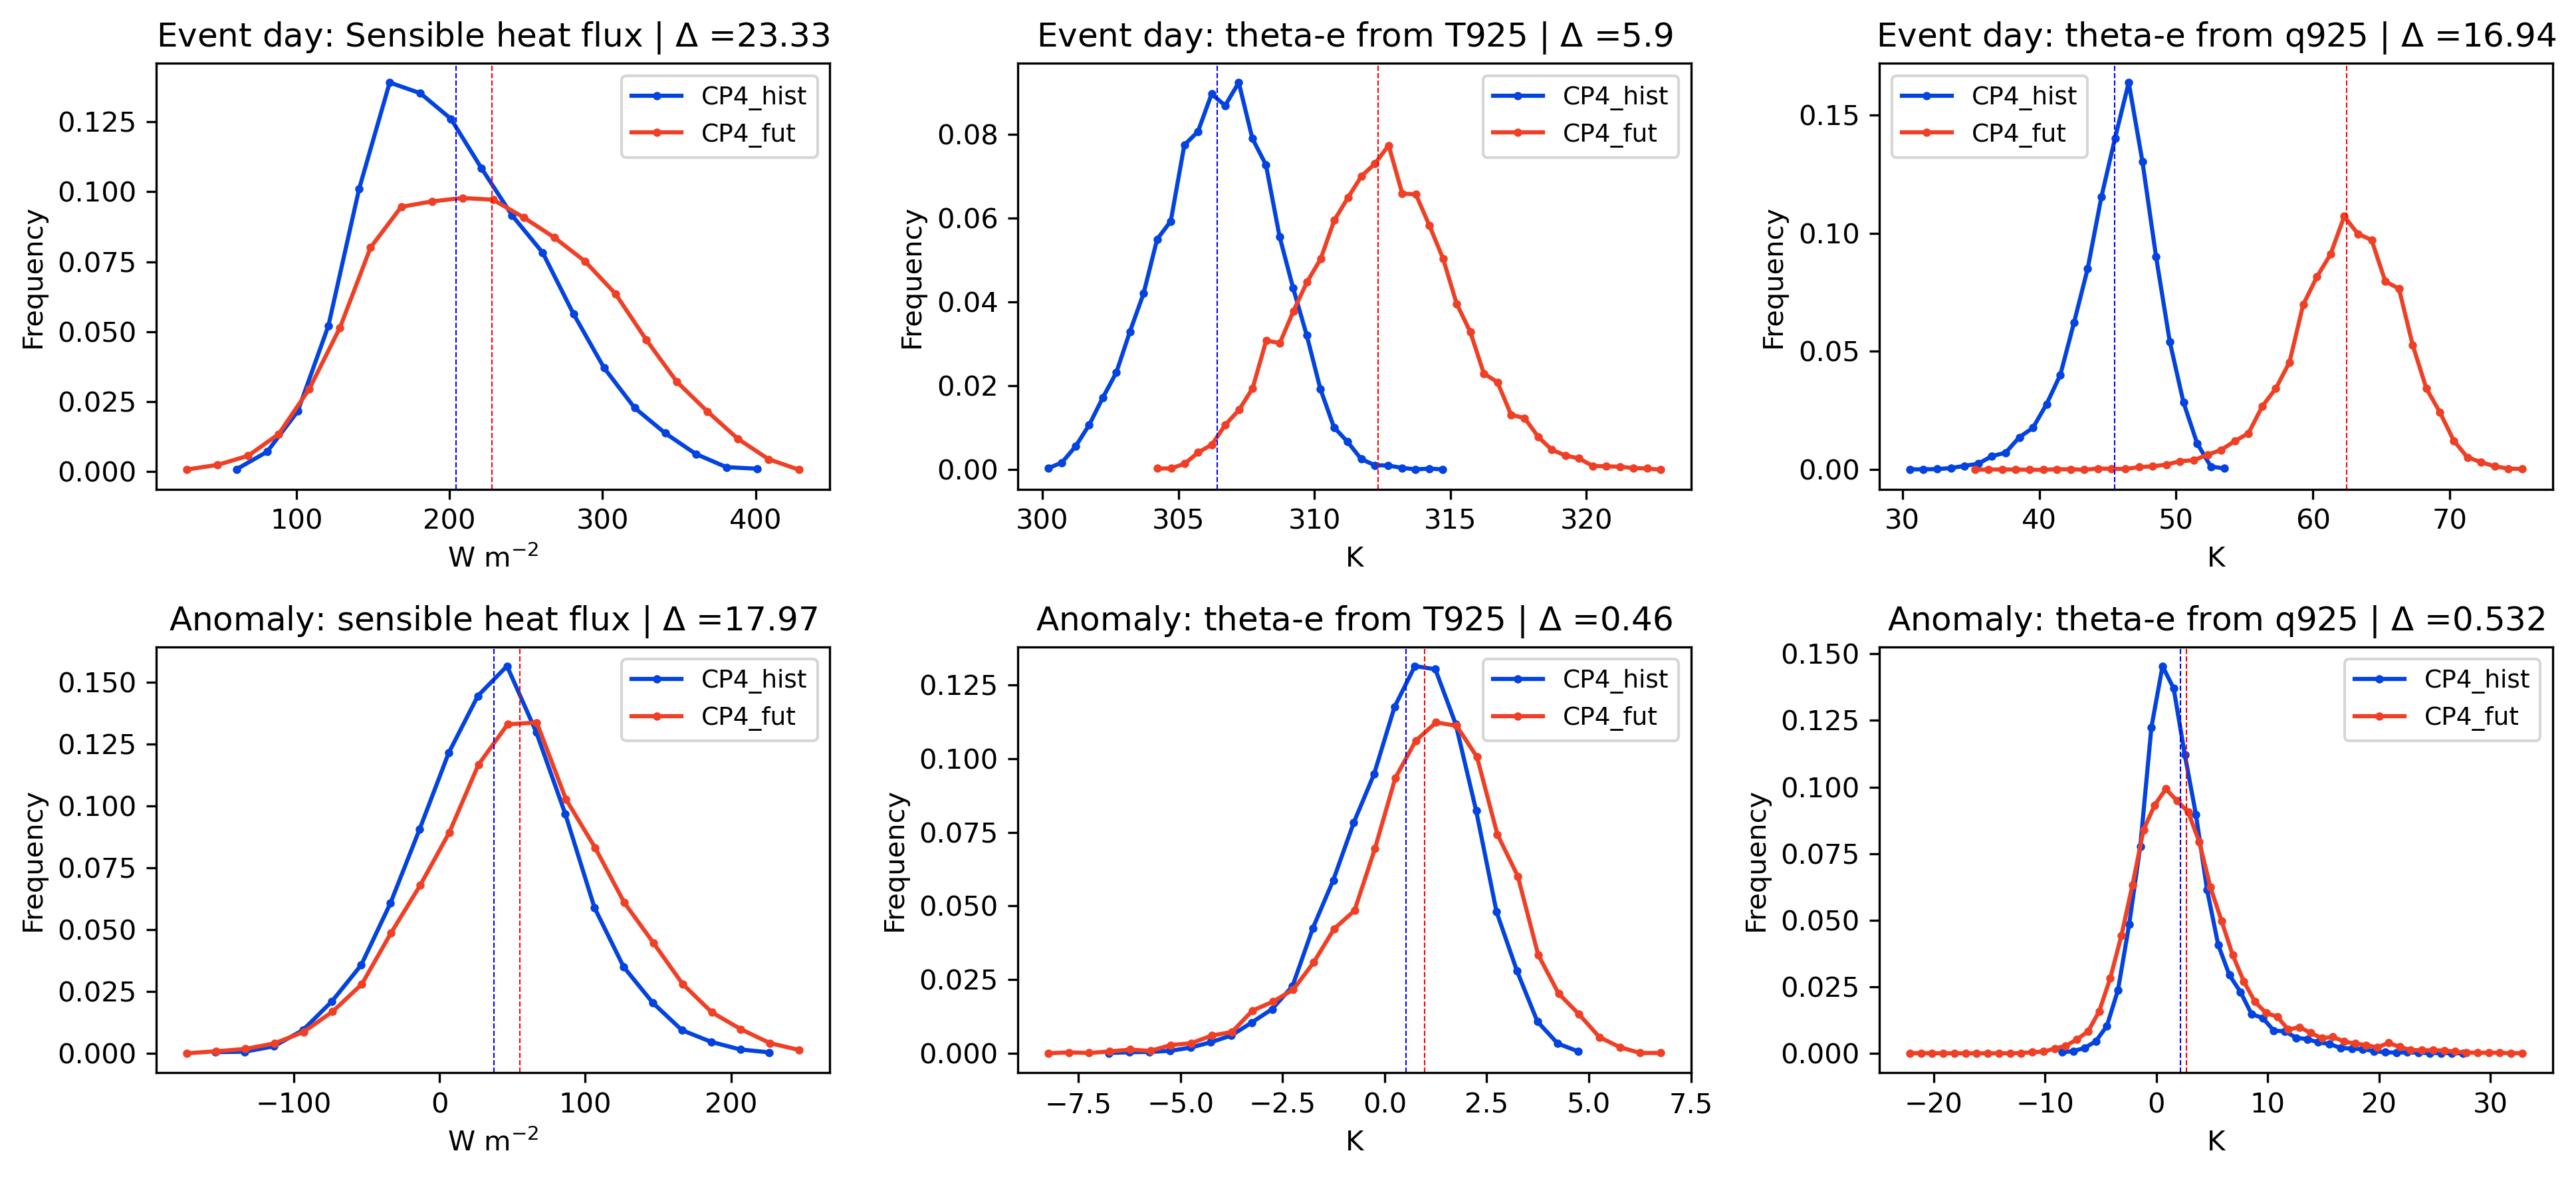

In [55]:
f = plt.figure(figsize=(13,6), dpi=300)



ax = f.add_subplot(231)

var = 'sh_1deg'
efplot = lhist[var]
efhist = efplot
efplot = lfut[var]
effut = efplot
cp4 = hist2d.basic_1d_binning(efhist, np.arange(np.min(efhist), np.max(efhist),20))
cp4f = hist2d.basic_1d_binning(effut, np.arange(np.min(effut), np.max(effut),20))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('W m$^{-2}$')
plt.title('Event day: Sensible heat flux | $\Delta$ ='+str(np.round(np.nanmean(effut)-np.nanmean(efhist),2)))
ax.axvline(np.nanmean(efhist), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanmean(effut), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)


ax = f.add_subplot(232)

var = 'theta'

thet_hist = lhist[var]
thet_fut = lfut[var]

cp4 = hist2d.basic_1d_binning(thet_hist, np.arange(np.min(thet_hist), np.max(thet_hist),0.5))
cp4f = hist2d.basic_1d_binning(thet_fut, np.arange(np.min(thet_fut), np.max(thet_fut),0.5))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('K')
plt.title('Event day: theta-e from T925 | $\Delta$ ='+str(np.round(np.nanmean(lfut[var])-np.nanmean(lhist[var]),2)))
ax.axvline(np.nanmean(lhist[var]), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanmean(lfut[var]), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)


ax = f.add_subplot(233)

var = 'theta-e'
cp4 = hist2d.basic_1d_binning(lhist[var]-thet_hist, np.arange(np.min(lhist[var]-thet_hist), np.max(lhist[var]-thet_hist),1))
cp4f = hist2d.basic_1d_binning(lfut[var]-thet_fut, np.arange(np.min(lfut[var]-thet_fut), np.max(lfut[var]-thet_fut),1))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('K')
plt.title('Event day: theta-e from q925 | $\Delta$ ='+str(np.round(np.nanmean(lfut[var]-thet_fut)-np.nanmean(lhist[var]-thet_hist),2)))
ax.axvline(np.nanmean(lhist[var]-thet_hist), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanmean(lfut[var]-thet_fut), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)



ax = f.add_subplot(234)

var = 'sh_1deg'
efplot = lahist[var]
efhist = efplot
efplot = lafut[var]
effut = efplot
cp4 = hist2d.basic_1d_binning(efhist, np.arange(np.min(efhist), np.max(efhist),20))
cp4f = hist2d.basic_1d_binning(effut, np.arange(np.min(effut), np.max(effut),20))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('W m$^{-2}$')
plt.title('Anomaly: sensible heat flux | $\Delta$ ='+str(np.round(np.nanmean(effut)-np.nanmean(efhist),2))) 
ax.axvline(np.nanmean(efhist), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanmean(effut), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)


ax = f.add_subplot(235)

var = 'theta'

thet_hist = lahist[var]
thet_fut = lafut[var]

cp4 = hist2d.basic_1d_binning(thet_hist, np.arange(np.min(thet_hist), np.max(thet_hist),0.5))
cp4f = hist2d.basic_1d_binning(thet_fut, np.arange(np.min(thet_fut), np.max(thet_fut),0.5))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('K')
plt.title('Anomaly: theta-e from T925 | $\Delta$ ='+str(np.round(np.nanmean(lafut[var])-np.nanmean(lahist[var]),2))) 
ax.axvline(np.nanmean(lahist[var]), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanmean(lafut[var]), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)


ax = f.add_subplot(236)

var = 'theta-e'
cp4 = hist2d.basic_1d_binning(lahist[var]-thet_hist, np.arange(np.min(lahist[var]-thet_hist), np.max(lahist[var]-thet_hist),1))
cp4f = hist2d.basic_1d_binning(lafut[var]-thet_fut, np.arange(np.min(lafut[var]-thet_fut), np.max(lafut[var]-thet_fut),1))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('K')
plt.title('Anomaly: theta-e from q925 | $\Delta$ ='+str(np.round(np.nanmean(lafut[var]-thet_fut)-np.nanmean(lahist[var]-thet_hist),3)))
ax.axvline(np.nanmean(lahist[var]-thet_hist), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanmean(lafut[var]-thet_fut), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)
plt.tight_layout()
#f.savefig(cnst.network_data + 'figs/LMCS/CP4_PNASstudy/theta_variable_distributions_100km-Box.jpg')

In [56]:
print(list(lhist.keys()))

['tcwv_0.25deg', 'sh_0.25deg', 'lh_0.25deg', 't2_0.25deg', 'q2_0.25deg', 'pblH_0.25deg', 'shear_0.25deg', 'u_mid_0.25deg', 'u_srfc_0.25deg', 'v_mid_0.25deg', 'v_srfc_0.25deg', 'q_mid_0.25deg', 't_mid_0.25deg', 't_srfc_0.25deg', 'q_srfc_0.25deg', 'geoH_srfc_0.25deg', 'lsRain_noon_0.25deg', 'lwout_noon_0.25deg', 'SM_0.25deg', 'lw_net_0.25deg', 'sw_in_0.25deg', 'sw_net_0.25deg', 'u10_0.25deg', 'v10_0.25deg', 'tcwv_1deg', 'sh_1deg', 'lh_1deg', 't2_1deg', 'q2_1deg', 'pblH_1deg', 'shear_1deg', 'u_mid_1deg', 'u_srfc_1deg', 'v_mid_1deg', 'v_srfc_1deg', 'q_mid_1deg', 't_mid_1deg', 't_srfc_1deg', 'q_srfc_1deg', 'geoH_srfc_1deg', 'lsRain_noon_1deg', 'lwout_noon_1deg', 'SM_1deg', 'lw_net_1deg', 'sw_in_1deg', 'sw_net_1deg', 'u10_1deg', 'v10_1deg', 'tcwv_2deg', 'sh_2deg', 'lh_2deg', 't2_2deg', 'q2_2deg', 'pblH_2deg', 'shear_2deg', 'u_mid_2deg', 'u_srfc_2deg', 'v_mid_2deg', 'v_srfc_2deg', 'q_mid_2deg', 't_mid_2deg', 't_srfc_2deg', 'q_srfc_2deg', 'geoH_srfc_2deg', 'lsRain_noon_2deg', 'lwout_noon_2deg'

PearsonRResult(statistic=-0.4753003463154765, pvalue=0.0)
PearsonRResult(statistic=-0.09212493495358248, pvalue=3.226561412758977e-22)
PearsonRResult(statistic=-0.39896305842702295, pvalue=0.0)


Text(0.5, 1.0, 'sh versus tcwv')

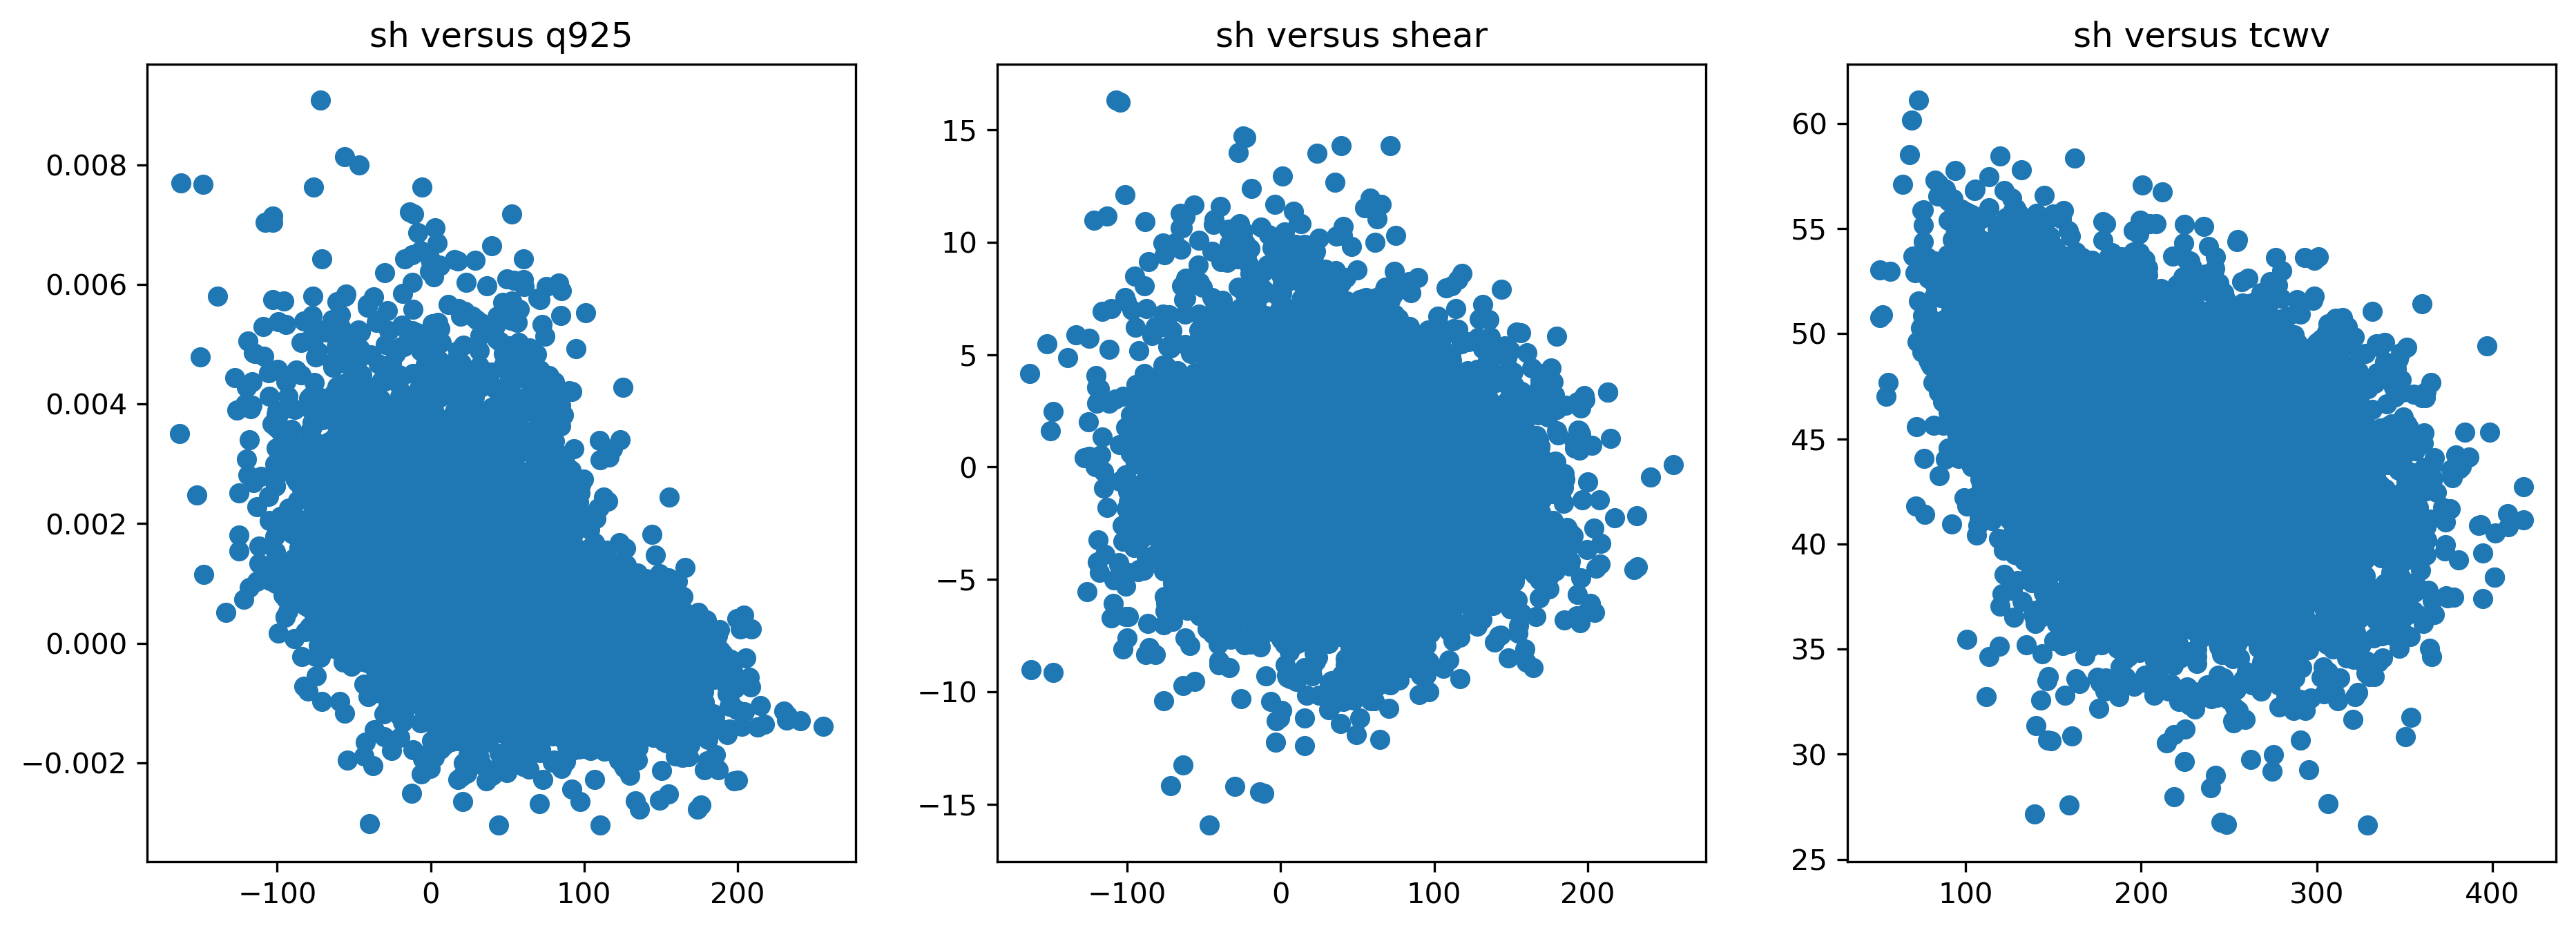

In [117]:
f = plt.figure(figsize=(15,5), dpi=300)
ax = f.add_subplot(131)
a=lahist['q_srfc_1deg']
b=lahist['sh_1deg']
a = a[np.isfinite(a)&np.isfinite(b)]
b = b[np.isfinite(a)&np.isfinite(b)]
plt.scatter(b,a)
print(stats.pearsonr(b, a))
plt.title('sh versus q925')

ax = f.add_subplot(132)
a=lahist['u_mid_1deg']-lahist['u10_1deg']
b=lahist['sh_1deg']
a = a[np.isfinite(a)&np.isfinite(b)]
b = b[np.isfinite(a)&np.isfinite(b)]
plt.scatter(b,a)
print(stats.pearsonr(b, a))
plt.title('sh versus shear')

ax = f.add_subplot(133)
a=lhist['tcwv_1deg']
b=lhist['sh_1deg']
a = a[np.isfinite(a)&np.isfinite(b)]
b = b[np.isfinite(a)&np.isfinite(b)]
plt.scatter(b,a)
print(stats.pearsonr(b, a))
plt.title('sh versus tcwv')

## ALL NEGATIVELY CORRELATED WITH SH

PearsonRResult(statistic=-0.44057460242797164, pvalue=1.047589187516028e-164)
PearsonRResult(statistic=-0.09899507004185336, pvalue=3.729979620421411e-09)
PearsonRResult(statistic=-0.488228909586644, pvalue=5.245526929078153e-211)


Text(0.5, 1.0, 'sh versus tcwv')

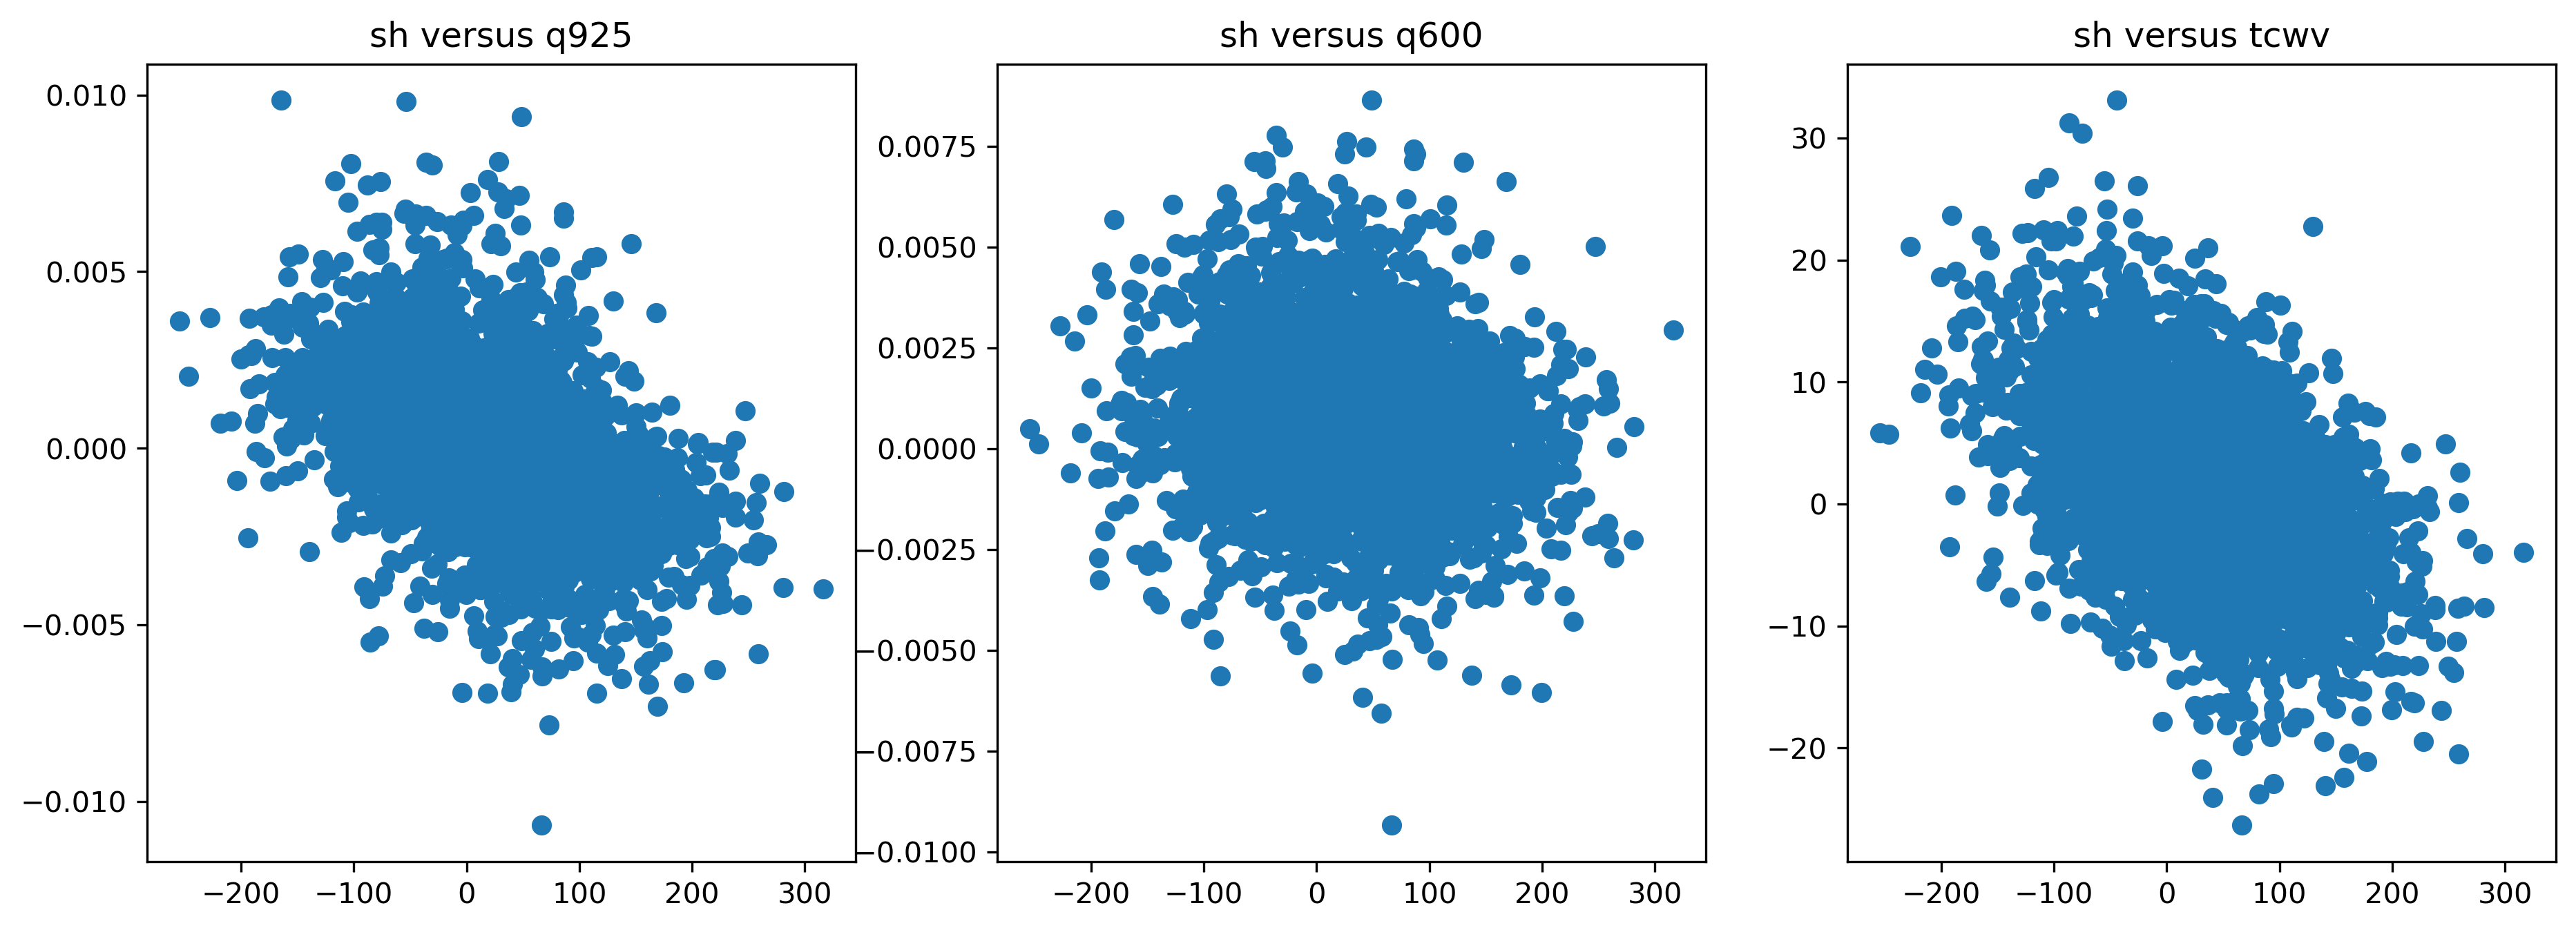

In [58]:
f = plt.figure(figsize=(15,5), dpi=300)
ax = f.add_subplot(131)
a=lafut['q_srfc_1deg']-lahist['q_srfc_1deg']
b=lafut['sh_1deg']-lahist['sh_1deg']
a = a[np.isfinite(a)&np.isfinite(b)]
b = b[np.isfinite(a)&np.isfinite(b)]
plt.scatter(b,a)
print(stats.pearsonr(b, a))
plt.title('sh versus q925')

ax = f.add_subplot(132)
a=lafut['q_mid_1deg']-lahist['q_mid_1deg']
b=lafut['sh_1deg']-lahist['sh_1deg']
a = a[np.isfinite(a)&np.isfinite(b)]
b = b[np.isfinite(a)&np.isfinite(b)]
plt.scatter(b,a)
print(stats.pearsonr(b, a))
plt.title('sh versus q600')

ax = f.add_subplot(133)
a=lafut['tcwv_1deg']-lahist['tcwv_1deg']
b=lafut['sh_1deg']-lahist['sh_1deg']
a = a[np.isfinite(a)&np.isfinite(b)]
b = b[np.isfinite(a)&np.isfinite(b)]
plt.scatter(b,a)
print(stats.pearsonr(b, a))
plt.title('sh versus tcwv')

## ALL NEGATIVELY CORRELATED WITH SH

NameError: name 'da_fut' is not defined

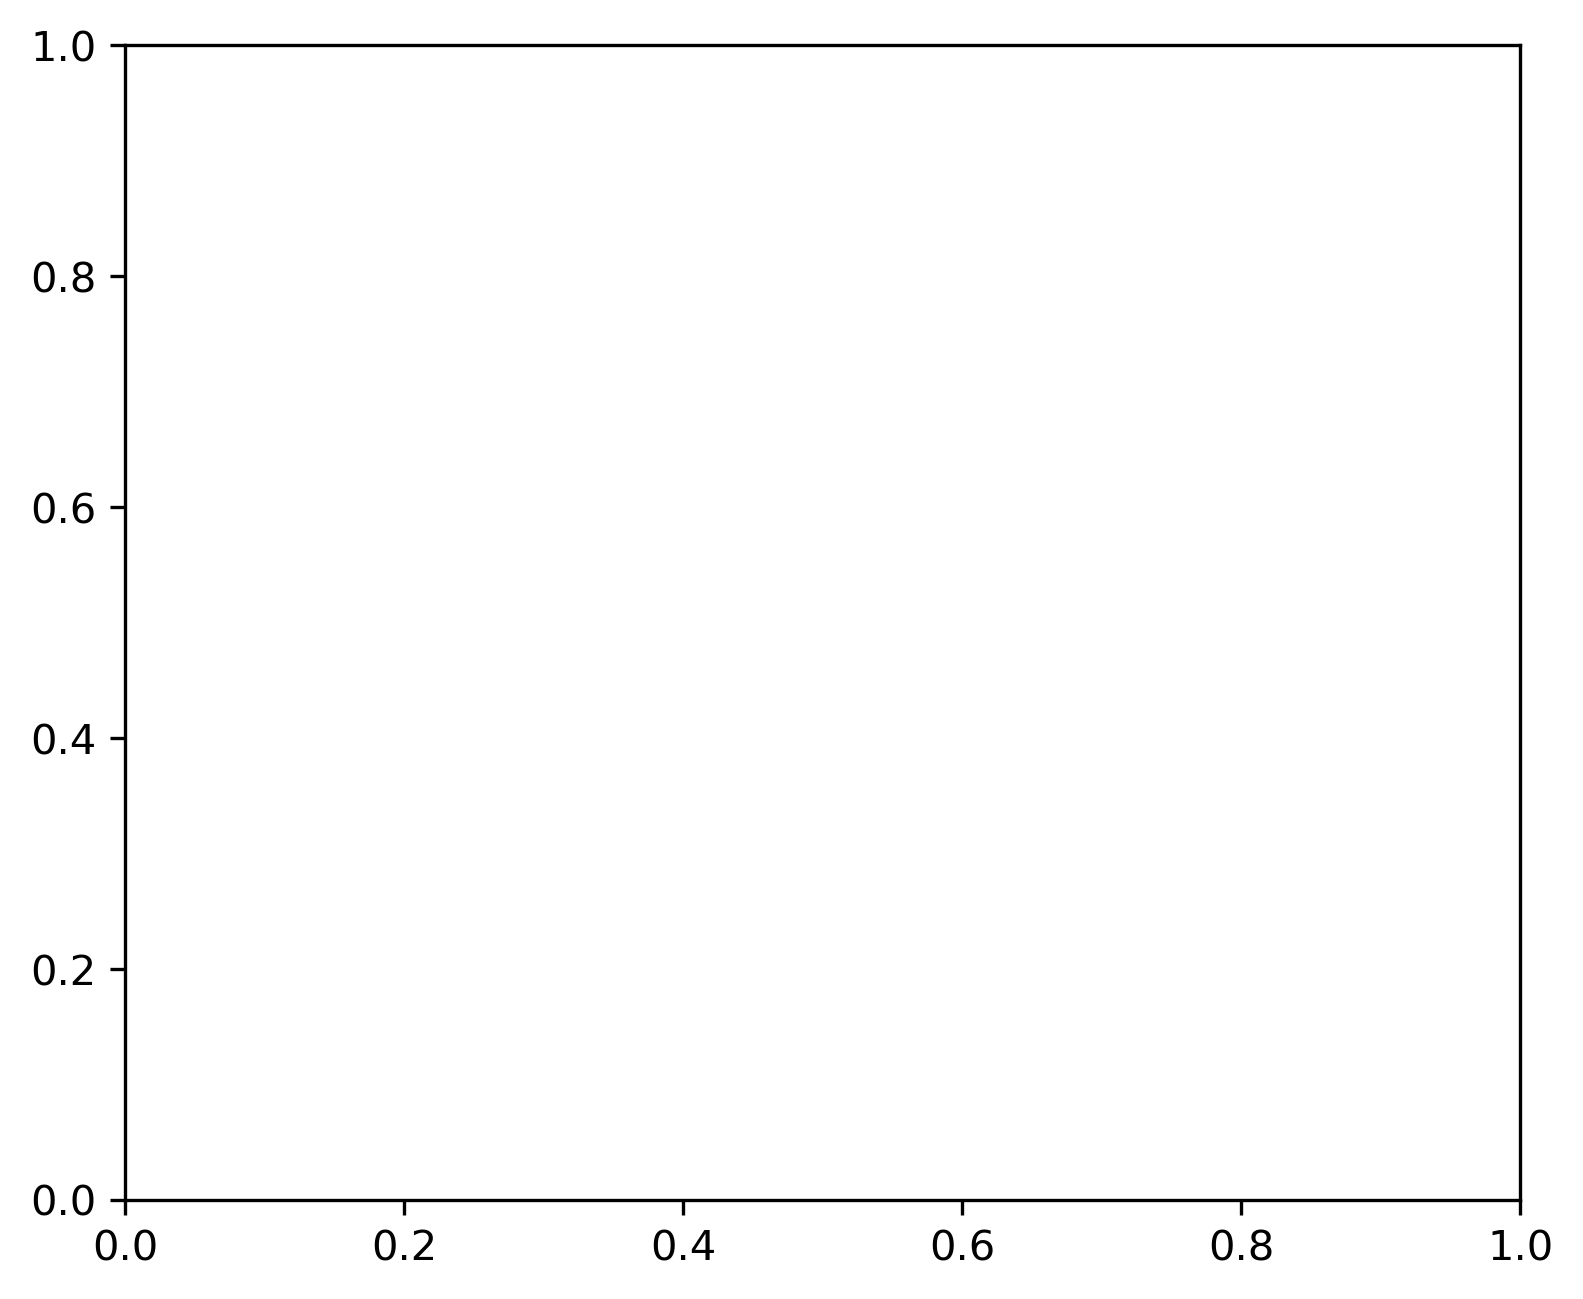

In [320]:
f = plt.figure(figsize=(6,5), dpi=300)
mname = 'node'
extent = 57 #* 4.4

ticks = np.array([0,58-57/2,58,58+57/2,114])
#labels = np.rint([-57*4.4,-57/2*4.4,0,57/2*4.4, 57*4.4])
labels = [-250,-125,0,125,250]
box = [57-22, 57+22, 57-22, 57+22]

ax = f.add_subplot(1,1,1)
ano =da_fut['lsRain']#-da_hist['lsRain'])
cont = da_hist['lsRain']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(cont, cmap='PuBu', extend='both', levels=[0,3,6,9])
plt.colorbar(label='Historical rainfall (mm h$^{-1}$)')
plt.contour(ano, colors='red', levels=[-10,3], linewidths=0.5)#levels=np.linspace(thresh * -1, thresh, 10)

plt.title('Historical storm rainfall composite | red: future 3mm/h area')
cm = ax.contour(cont, colors='k', levels=[-10, 3], linewidths=1)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='turquoise')

# pv, pw = da_hist_anom['u_srfc'].values, da_hist_anom['v_srfc'].values
# qv = plt.quiver(np.arange(da_hist.longitude.shape[0])[::10], np.arange(da_hist.latitude.shape[0])[::10], pv[::10,::10], pw[::10,::10])

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


# ax = f.add_subplot(1,2,2)

# pos = da_fut

# ano =da_fut['lsRain']#-da_his
# cont = da_hist['lsRain']

# thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

# plt.contourf(ano, cmap='PuBu', extend='both', levels=[3,6,9])
# plt.colorbar(label='$\Delta$ Rainfall (mm h$^{-1}$)')
# plt.contour(ano, colors='red', levels=[-5,3], linewidths=0.5)#levels=np.linspace(thresh * -1, thresh, 10)

# plt.title('black: Historical rainfall mean (mm h$^{-1}$)')
# cm = ax.contour(cont, colors='k', levels=[-5, 3], linewidths=1)
# ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='turquoise')

# # pv, pw = da_hist_anom['u_srfc'].values, da_hist_anom['v_srfc'].values
# # qv = plt.quiver(np.arange(da_hist.longitude.shape[0])[::10], np.arange(da_hist.latitude.shape[0])[::10], pv[::10,::10], pw[::10,::10])

# plt.plot(extent, extent, 'bo')
# ax.set_xlabel('km')
# ax.set_ylabel('km')
# ax.set_xticks(ticks)
# ax.set_xticklabels(labels)
# ax.set_yticks(ticks)
# ax.set_yticklabels(labels)


plt.tight_layout()
#f.savefig(cnst.network_data + 'figs/LMCS/CP4_PNASstudy/area_change.jpg')

In [131]:
histp25, histp75 = np.nanpercentile(lahist['sh_1deg'], [25,75])
futp25, futp75 = np.nanpercentile(lafut['sh_1deg'], [25,75])

In [132]:
print(histp25, histp75)

0.2806824156096314 71.28759432854383


In [133]:
print(futp25, futp75)

12.513294746083284 93.72089684897904


In [137]:
histp25 = 15.958349028364086 
histp75 = 74.97727916408145
futp25 = 26.155087241384514 
futp75 = 100.0292799740854

In [138]:
histposlow = lahist['sh_1deg'] < histp25
histposhigh = lahist['sh_1deg'] > histp75

futposlow = lafut['sh_1deg'] < futp25
futposhigh = lafut['sh_1deg'] > futp75

t2 wet 1424586.0 8.333003637562504e-17
t2 dry 295225.0 4.48886912370003e-151
t2 wet 1430260.0 3.615539354926039e-16
t2 dry 420435.0 3.193928316732735e-81
t2 wet 1033107.0 6.874665717353953e-93
t2 dry 385314.0 1.2908859301483183e-98
allcase difference 13.730084779874787
drycase difference 14.646799260509173
allcase difference rel to hist 0.6614708161560661
drycase difference rel to hist 0.6441840265293801
t2 wet 1033107.0 6.874665717353953e-93
t2 dry 385314.0 1.2908859301483183e-98
SUMTEST 3.552713678800501e-15
allcase difference 13.730084779874787
drycase difference 14.646799260509173
allcase difference rel to hist 0.6614708161560661
drycase difference rel to hist 0.6441840265293801


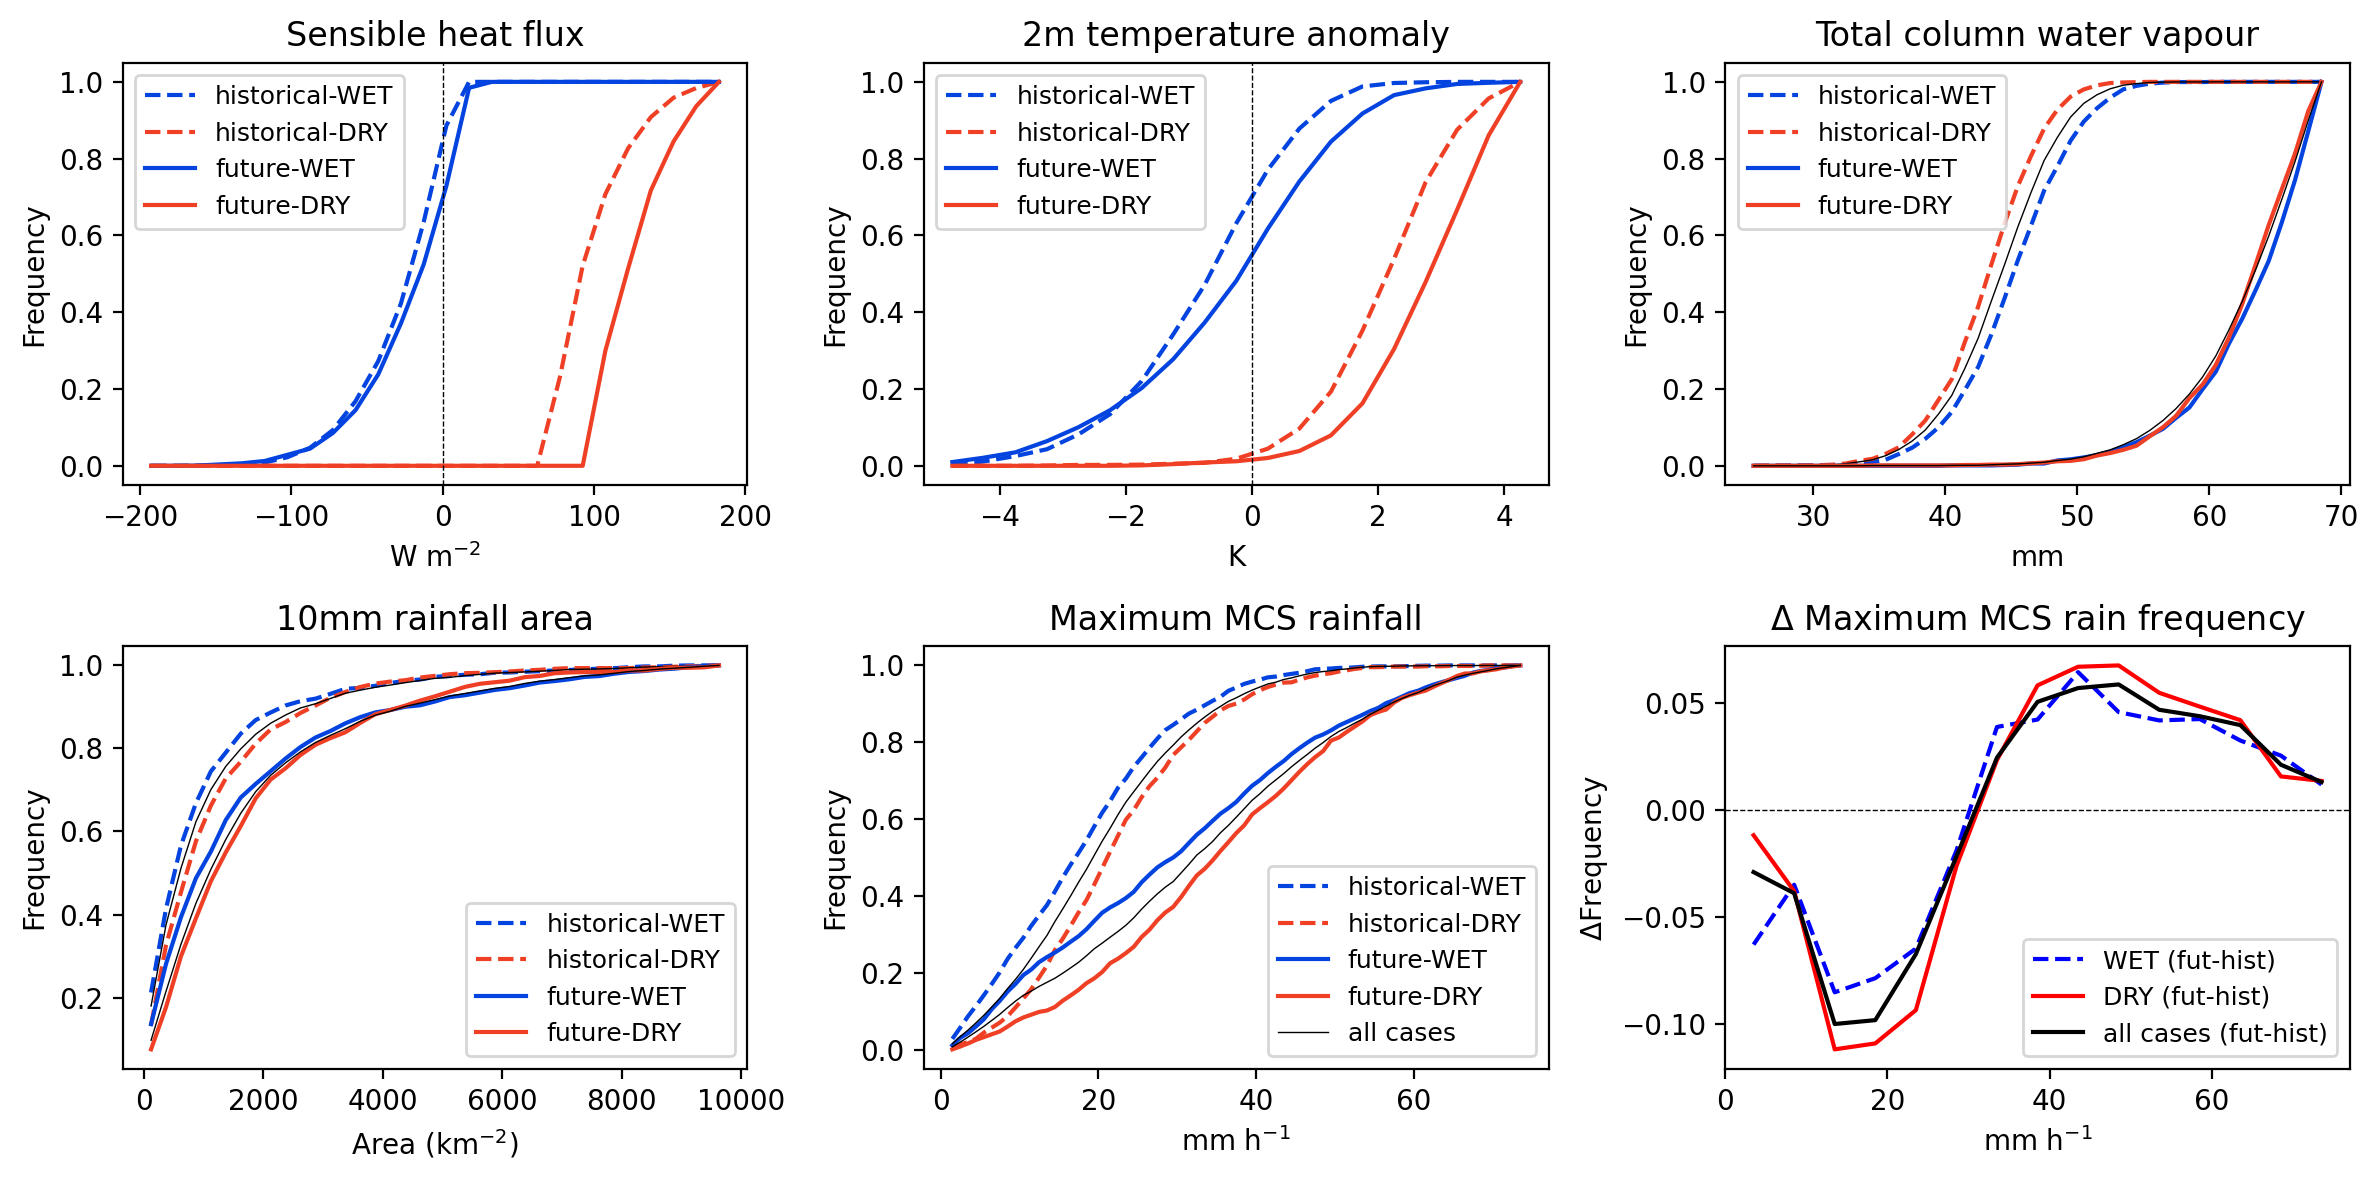

In [139]:
f = plt.figure(figsize=(12,6), dpi=200)



ax1 = f.add_subplot(231)

var = 'sh_1deg'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]


cp4 = hist2d.basic_1d_binning(low, np.arange(-200, 200,15))
cp4f = hist2d.basic_1d_binning(high, np.arange(-200, 200,15))
alle = hist2d.basic_1d_binning(alls, np.arange(-200, 200,15))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(-200, 200,15))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(-200, 200,15))
falle = hist2d.basic_1d_binning(falls, np.arange(-200, 200,15))



bins=cp4['xbins']

cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

stat, pval = stats.mannwhitneyu(low, flow, nan_policy='omit')
print('t2 wet', stat,pval)
stat, pval = stats.mannwhitneyu(high, fhigh, nan_policy='omit')
print('t2 dry', stat,pval)

plt.plot(bins, cumlow, color='xkcd:blue', label='historical-WET', linestyle='dashed')
plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')
#plt.plot(bins, cumall, color='k', label='future' )

plt.plot(bins, fcumlow, color='xkcd:blue', label='future-WET' )
plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
ax1.axvline(0, color='k', linestyle='dashed', linewidth=0.5)
#plt.plot(bins, fcumall, color='grey', label='future' )


plt.ylabel('Frequency')
plt.xlabel('W m$^{-2}$')
plt.title('Sensible heat flux')
plt.legend(fontsize=9)
plt.legend(fontsize=9)


ax1 = f.add_subplot(232)

var = 't2_1deg'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]


cp4 = hist2d.basic_1d_binning(low, np.arange(-5, 5,0.5))
cp4f = hist2d.basic_1d_binning(high, np.arange(-5, 5,0.5))
alle = hist2d.basic_1d_binning(alls, np.arange(-5, 5,0.5))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(-5, 5,0.5))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(-5, 5,0.5))
falle = hist2d.basic_1d_binning(falls, np.arange(-5, 5,0.5))



bins=cp4['xbins']

cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

stat, pval = stats.mannwhitneyu(low, flow, nan_policy='omit')
print('t2 wet', stat,pval)
stat, pval = stats.mannwhitneyu(high, fhigh, nan_policy='omit')
print('t2 dry', stat,pval)

plt.plot(bins, cumlow, color='xkcd:blue', label='historical-WET', linestyle='dashed')
plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')
#plt.plot(bins, cumall, color='k', label='future' )

plt.plot(bins, fcumlow, color='xkcd:blue', label='future-WET' )
plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
#plt.plot(bins, fcumall, color='grey', label='future' )


plt.ylabel('Frequency')
plt.xlabel('K')
plt.title('2m temperature anomaly')
plt.legend(fontsize=9)
plt.legend(fontsize=9)
ax1.axvline(0, color='k', linestyle='dashed', linewidth=0.5)


ax1 = f.add_subplot(233)

var = 'tcwv_cl'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]


cp4 = hist2d.basic_1d_binning(low, np.arange(25, 70,1))
cp4f = hist2d.basic_1d_binning(high, np.arange(25, 70,1))
alle = hist2d.basic_1d_binning(alls, np.arange(25, 70,1))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(25, 70,1))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(25, 70,1))
falle = hist2d.basic_1d_binning(falls, np.arange(25, 70,1))

bins=cp4['xbins']

cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

plt.plot(bins, cumlow, color='xkcd:blue', label='historical-WET', linestyle='dashed')
plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')
plt.plot(bins, cumall, color='k', linewidth=0.5)

plt.plot(bins, fcumlow, color='xkcd:blue', label='future-WET' )
plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
plt.plot(bins, fcumall, color='k', linewidth=0.5)


plt.ylabel('Frequency')
plt.xlabel('mm')
plt.title('Total column water vapour')
plt.legend(fontsize=9)
plt.legend(fontsize=9)


ax = f.add_subplot(234)

var = 'area_10mm'
low = lahist[var][histposlow]*(4.4*4.4)
high = lahist[var][histposhigh]*(4.4*4.4)
alls = lahist[var]*(4.4*4.4)

flow = lafut[var][futposlow]*(4.4*4.4)
fhigh = lafut[var][futposhigh]*(4.4*4.4)
falls = lafut[var]*(4.4*4.4)


cp4 = hist2d.basic_1d_binning(low, np.arange(1, 10000,250))
cp4f = hist2d.basic_1d_binning(high, np.arange(1, 10000,250))
alle = hist2d.basic_1d_binning(alls, np.arange(1, 10000,250))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(1, 10000,250))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(1, 10000,250))
falle = hist2d.basic_1d_binning(falls, np.arange(1, 10000,250))


bins=cp4['xbins']

cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

plt.plot(bins, cumlow, color='xkcd:blue', label='historical-WET', linestyle='dashed')
plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')
plt.plot(bins, cumall, color='k', linewidth=0.5)

plt.plot(bins, fcumlow, color='xkcd:blue', label='future-WET' )
plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
plt.plot(bins, fcumall, color='k', linewidth=0.5)

plt.ylabel('Frequency')
plt.xlabel('Area (km$^{-2}$)')
plt.title('10mm rainfall area')

plt.legend(fontsize=9)



ax1 = f.add_subplot(235)

var = 'pmax'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]


cp4 = hist2d.basic_1d_binning(low, np.arange(1, 75,1))
cp4f = hist2d.basic_1d_binning(high, np.arange(1, 75,1))
alle = hist2d.basic_1d_binning(alls, np.arange(1, 75,1))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(1, 75,1))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(1, 75,1))
falle = hist2d.basic_1d_binning(falls, np.arange(1, 75,1))



bins=cp4['xbins']

cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

stat, pval = stats.mannwhitneyu(low, flow, nan_policy='omit')
print('t2 wet', stat,pval)
stat, pval = stats.mannwhitneyu(high, fhigh, nan_policy='omit')
print('t2 dry', stat,pval)

plt.plot(bins, cumlow, color='xkcd:blue', label='historical-WET', linestyle='dashed')
plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')


plt.plot(bins, fcumlow, color='xkcd:blue', label='future-WET' )
plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
plt.plot(bins, fcumall, color='k', linewidth=0.5)
plt.plot(bins, cumall, color='k', label='all cases', linewidth=0.5)

print('allcase difference', np.nanmean(falls)-np.nanmean(alls))
print('drycase difference', np.nanmean(fhigh)-np.nanmean(high))

print('allcase difference rel to hist', (np.nanmean(falls)-np.nanmean(alls))/np.nanmean(alls))
print('drycase difference rel to hist', (np.nanmean(fhigh)-np.nanmean(high))/np.nanmean(high))

plt.ylabel('Frequency')
plt.xlabel('mm h$^{-1}$')
plt.title('Maximum MCS rainfall')
plt.legend(fontsize=9)
plt.legend(fontsize=9)

ax1 = f.add_subplot(236)

var = 'pmax'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]


cp4 = hist2d.basic_1d_binning(low, np.arange(1, 81,5))
cp4f = hist2d.basic_1d_binning(high, np.arange(1, 81,5))
alle = hist2d.basic_1d_binning(alls, np.arange(1, 81,5))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(1, 81,5))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(1, 81,5))
falle = hist2d.basic_1d_binning(falls, np.arange(1, 81,5))
ax1.axhline(0, linestyle='dashed', color='k', linewidth=0.5)


bins=cp4['xbins']

# cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
# cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
# cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

# fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
# fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
# fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

cumlow = (cp4['nb']/np.sum(cp4['nb']))
cumhigh = (cp4f['nb']/np.sum(cp4f['nb']))
cumall = (alle['nb']/np.sum(alle['nb']))

fcumlow = (fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = (fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = (falle['nb']/np.sum(falle['nb']))

stat, pval = stats.mannwhitneyu(low, flow, nan_policy='omit')
print('t2 wet', stat,pval)
stat, pval = stats.mannwhitneyu(high, fhigh, nan_policy='omit')
print('t2 dry', stat,pval)

plt.plot(bins, fcumlow-cumlow, color='b', label='WET (fut-hist)', linestyle='dashed')
#plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')


plt.plot(bins, fcumhigh-cumhigh, color='r', label='DRY (fut-hist)' )
plt.plot(bins, fcumall-cumall, color='k', label='all cases (fut-hist)' )
#plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
# plt.plot(bins, fcumall, color='k', linewidth=0.5)
# plt.plot(bins, cumall, color='k', label='all cases', linewidth=0.5)

print('SUMTEST', np.sum((fcumhigh-cumhigh)*100))


print('allcase difference', np.nanmean(falls)-np.nanmean(alls))
print('drycase difference', np.nanmean(fhigh)-np.nanmean(high))

print('allcase difference rel to hist', (np.nanmean(falls)-np.nanmean(alls))/np.nanmean(alls))
print('drycase difference rel to hist', (np.nanmean(fhigh)-np.nanmean(high))/np.nanmean(high))
# perc = 75
# print('allcase difference', np.nanpercentile(falls, perc)-np.nanpercentile(alls, perc))
# print('drycase difference', np.nanpercentile(fhigh, perc)-np.nanpercentile(high, perc))

# print('allcase difference rel to hist', (np.nanpercentile(falls, perc)-np.nanpercentile(alls, perc))/np.nanpercentile(alls, perc))
# print('drycase difference rel to hist', (np.nanpercentile(fhigh, perc)-np.nanpercentile(high, perc))/np.nanpercentile(high, perc))

plt.ylabel('$\Delta$Frequency')
plt.xlabel('mm h$^{-1}$')
plt.title('$\Delta$ Maximum MCS rain frequency')
plt.legend(fontsize=9)
plt.legend(fontsize=9)


plt.tight_layout()
#f.savefig(cnst.network_data + 'figs/LMCS/CP4_PNASstudy/SHsplit_variable_distributions_100km-Box.jpg')

t2 wet 1424586.0 8.333003637562504e-17
t2 dry 295225.0 4.48886912370003e-151
t2 wet 1579072.0 0.0018486648553436027
t2 dry 666733.0 4.016621161640315e-07

t2 wet 1033107.0 6.874665717353953e-93
t2 dry 385314.0 1.2908859301483183e-98
allcase difference 13.730084779874787
drycase difference 14.646799260509173
allcase difference rel to hist 0.6614708161560661
drycase difference rel to hist 0.6441840265293801
Hist p99
50.0
42.50371103414151
58.049886621315196
Hist p99 in future
74.57264957264957
67.18377088305489
82.44541484716157
Hist p99 in fut versus in hist
24.572649572649567
24.68005984891338
24.395528225846377
Mean rainfall increase
24.655152603647792
25.796551579631412
24.40489781920077


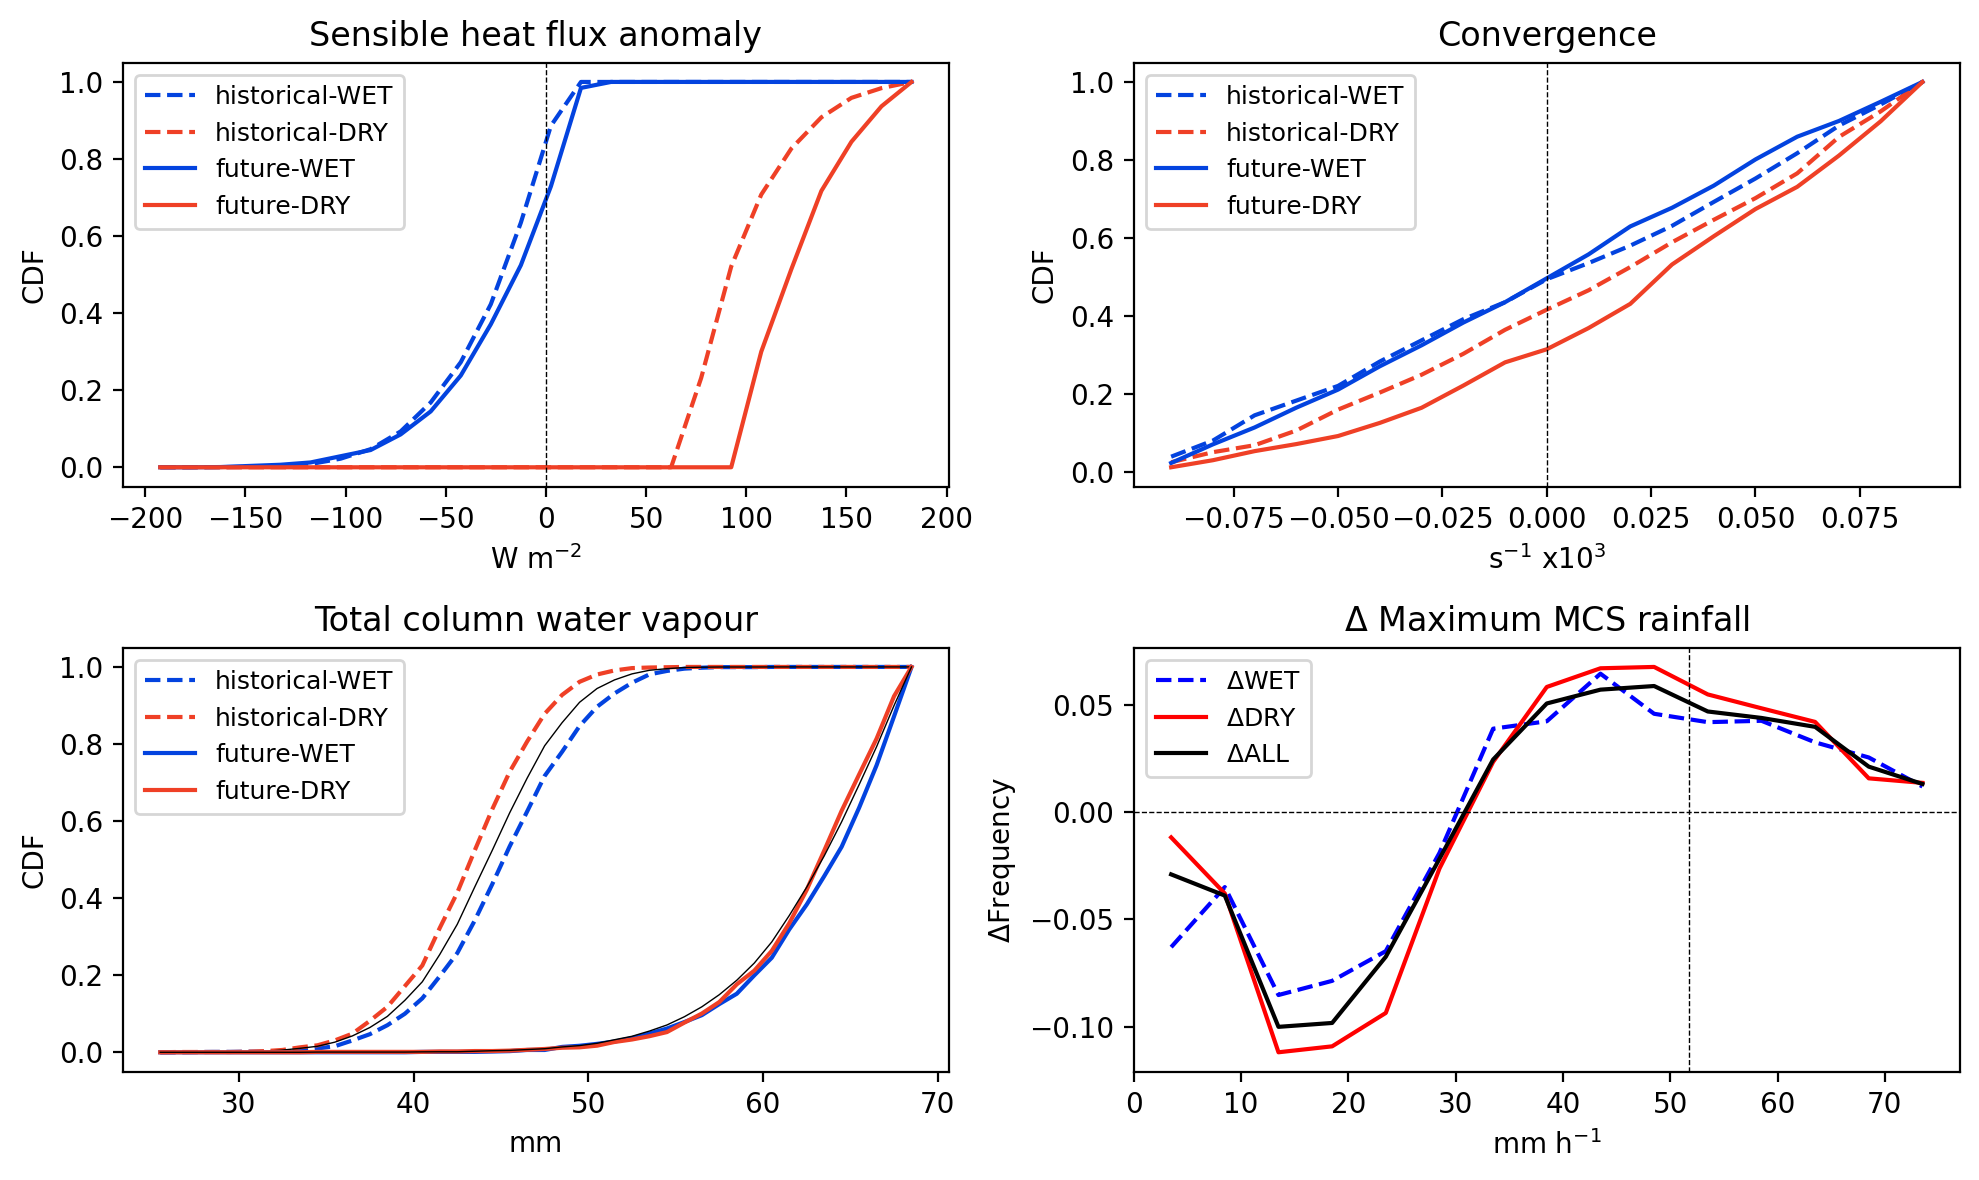

In [140]:
f = plt.figure(figsize=(10,6), dpi=200)



ax1 = f.add_subplot(221)

var = 'sh_1deg'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]


cp4 = hist2d.basic_1d_binning(low, np.arange(-200, 200,15))
cp4f = hist2d.basic_1d_binning(high, np.arange(-200, 200,15))
alle = hist2d.basic_1d_binning(alls, np.arange(-200, 200,15))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(-200, 200,15))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(-200, 200,15))
falle = hist2d.basic_1d_binning(falls, np.arange(-200, 200,15))



bins=cp4['xbins']

cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

# cumlow = (cp4['nb']/np.sum(cp4['nb']))
# cumhigh = (cp4f['nb']/np.sum(cp4f['nb']))
# cumall = (alle['nb']/np.sum(alle['nb']))

# fcumlow = (fcp4['nb']/np.sum(fcp4['nb']))
# fcumhigh = (fcp4f['nb']/np.sum(fcp4f['nb']))
# fcumall = (falle['nb']/np.sum(falle['nb']))

stat, pval = stats.mannwhitneyu(low, flow, nan_policy='omit')
print('t2 wet', stat,pval)
stat, pval = stats.mannwhitneyu(high, fhigh, nan_policy='omit')
print('t2 dry', stat,pval)

plt.plot(bins, cumlow, color='xkcd:blue', label='historical-WET', linestyle='dashed')
plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')
#plt.plot(bins, cumall, color='k', label='future' )

plt.plot(bins, fcumlow, color='xkcd:blue', label='future-WET' )
plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
ax1.axvline(0, color='k', linestyle='dashed', linewidth=0.5)
#plt.plot(bins, fcumall, color='grey', label='future' )


plt.ylabel('CDF')
plt.xlabel('W m$^{-2}$')
plt.title('Sensible heat flux anomaly')
plt.legend(fontsize=9)
plt.legend(fontsize=9)


ax1 = f.add_subplot(222)

var = 'div'
low = lahist[var][histposlow]*-10000
high = lahist[var][histposhigh]*-10000
alls = lahist[var]*-10000

flow = lafut[var][futposlow]*-10000
fhigh = lafut[var][futposhigh]*-10000
falls = lafut[var]*-10000

ranges = np.linspace(-0.1, 0.1,20)

cp4 = hist2d.basic_1d_binning(low, ranges)
cp4f = hist2d.basic_1d_binning(high, ranges)
alle = hist2d.basic_1d_binning(alls, ranges)

fcp4 = hist2d.basic_1d_binning(flow, ranges)
fcp4f = hist2d.basic_1d_binning(fhigh, ranges)
falle = hist2d.basic_1d_binning(falls, ranges)



bins=cp4['xbins']

cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

# cumlow = (cp4['nb']/np.sum(cp4['nb']))
# cumhigh = (cp4f['nb']/np.sum(cp4f['nb']))
# cumall = (alle['nb']/np.sum(alle['nb']))

# fcumlow = (fcp4['nb']/np.sum(fcp4['nb']))
# fcumhigh = (fcp4f['nb']/np.sum(fcp4f['nb']))
# fcumall = (falle['nb']/np.sum(falle['nb']))


stat, pval = stats.mannwhitneyu(low, flow, nan_policy='omit')
print('t2 wet', stat,pval)
stat, pval = stats.mannwhitneyu(high, fhigh, nan_policy='omit')
print('t2 dry', stat,pval)

plt.plot(bins, cumlow, color='xkcd:blue', label='historical-WET', linestyle='dashed')
plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')
#plt.plot(bins, cumall, color='k', label='future' )

plt.plot(bins, fcumlow, color='xkcd:blue', label='future-WET' )
plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
#plt.plot(bins, fcumall, color='grey', label='future' )


plt.ylabel('CDF')
plt.xlabel('s$^{-1}$ x10$^{3}$')
plt.title('Convergence')
plt.legend(fontsize=9)
plt.legend(fontsize=9)
ax1.axvline(0, color='k', linestyle='dashed', linewidth=0.5)


ax1 = f.add_subplot(223)

var = 'tcwv_cl'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]


cp4 = hist2d.basic_1d_binning(low, np.arange(25, 70,1))
cp4f = hist2d.basic_1d_binning(high, np.arange(25, 70,1))
alle = hist2d.basic_1d_binning(alls, np.arange(25, 70,1))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(25, 70,1))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(25, 70,1))
falle = hist2d.basic_1d_binning(falls, np.arange(25, 70,1))

bins=cp4['xbins']

cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

# cumlow = (cp4['nb']/np.sum(cp4['nb']))
# cumhigh = (cp4f['nb']/np.sum(cp4f['nb']))
# cumall = (alle['nb']/np.sum(alle['nb']))

# fcumlow = (fcp4['nb']/np.sum(fcp4['nb']))
# fcumhigh = (fcp4f['nb']/np.sum(fcp4f['nb']))
# fcumall = (falle['nb']/np.sum(falle['nb']))

plt.plot(bins, cumlow, color='xkcd:blue', label='historical-WET', linestyle='dashed')
plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')
plt.plot(bins, cumall, color='k', linewidth=0.5)

plt.plot(bins, fcumlow, color='xkcd:blue', label='future-WET' )
plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
plt.plot(bins, fcumall, color='k', linewidth=0.5)


plt.ylabel('CDF')
plt.xlabel('mm')
plt.title('Total column water vapour')
plt.legend(fontsize=9)
plt.legend(fontsize=9)




ax1 = f.add_subplot(224)

var = 'pmax'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]


cp4 = hist2d.basic_1d_binning(low, np.arange(1, 81,5))
cp4f = hist2d.basic_1d_binning(high, np.arange(1, 81,5))
alle = hist2d.basic_1d_binning(alls, np.arange(1, 81,5))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(1, 81,5))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(1, 81,5))
falle = hist2d.basic_1d_binning(falls, np.arange(1, 81,5))

print()



bins=cp4['xbins']

# cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
# cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
# cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

# fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
# fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
# fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

cumlow = (cp4['nb']/np.sum(cp4['nb']))
cumhigh = (cp4f['nb']/np.sum(cp4f['nb']))
cumall = (alle['nb']/np.sum(alle['nb']))

fcumlow = (fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = (fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = (falle['nb']/np.sum(falle['nb']))

stat, pval = stats.mannwhitneyu(low, flow, nan_policy='omit')
print('t2 wet', stat,pval)
stat, pval = stats.mannwhitneyu(high, fhigh, nan_policy='omit')
print('t2 dry', stat,pval)

plt.plot(bins, fcumlow-cumlow, color='b', label='$\Delta$WET', linestyle='dashed')
plt.plot(bins, fcumhigh-cumhigh, color='r', label='$\Delta$DRY' )
plt.plot(bins, fcumall-cumall, color='k', label='$\Delta$ALL' )
# plt.plot(bins, cumlow, color='xkcd:blue', label='historical-WET', linestyle='dashed')
# plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')
# plt.plot(bins, cumall, color='k', linewidth=0.5)

# plt.plot(bins, fcumlow, color='xkcd:blue', label='future-WET' )
# plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
# plt.plot(bins, fcumall, color='k', linewidth=0.5)

#plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
# plt.plot(bins, fcumall, color='k', linewidth=0.5)
# plt.plot(bins, cumall, color='k', label='all cases', linewidth=0.5)

print('allcase difference', np.nanmean(falls)-np.nanmean(alls))
print('drycase difference', np.nanmean(fhigh)-np.nanmean(high))

print('allcase difference rel to hist', (np.nanmean(falls)-np.nanmean(alls))/np.nanmean(alls))
print('drycase difference rel to hist', (np.nanmean(fhigh)-np.nanmean(high))/np.nanmean(high))

plt.ylabel('$\Delta$Frequency')
plt.xlabel('mm h$^{-1}$')
plt.title('$\Delta$ Maximum MCS rainfall')
ax1.axhline(0,linestyle='dashed', color='k', linewidth=0.5)
#ax1.axvline(np.nanpercentile(high, 95), linestyle='dashed', color='r', linewidth=0.5)
#ax1.axvline(np.nanpercentile(low, 95), linestyle='dashed', color='b', linewidth=0.5)
ax1.axvline(np.nanpercentile(alls, 99), linestyle='dashed', color='k', linewidth=0.5)
p99 = np.percentile(alls,50)
print('Hist p99')
print(np.sum(alls>p99)/alls.size*100) #- np.sum(alls>p99)/alls.size)
print(np.sum(low>p99)/low.size*100)
print(np.sum(high>p99)/high.size*100)
print('Hist p99 in future')
print(np.sum(falls>p99)/falls.size*100)
print(np.sum(flow>p99)/flow.size*100)
print(np.sum(fhigh>p99)/fhigh.size*100)
print('Hist p99 in fut versus in hist')
print(np.sum(falls>p99)/falls.size*100 - np.sum(alls>p99)/alls.size*100) #- np.sum(alls>p99)/alls.size)
print(np.sum(flow>p99)/flow.size*100 - np.sum(low>p99)/low.size*100)
print(np.sum(fhigh>p99)/fhigh.size*100 - np.sum(high>p99)/high.size*100)

print('Mean rainfall increase')
print((np.percentile(falls, 90)-np.percentile(alls, 90)))
print((np.percentile(flow, 90)-np.percentile(low, 90)))
print((np.percentile(fhigh, 90)-np.percentile(high, 90)))

plt.legend(fontsize=9)
plt.legend(fontsize=9)

plt.tight_layout()
#f.savefig(cnst.network_data + 'figs/LMCS/CP4_PNASstudy/SHsplit_variable_distributions_100km-Box.jpg'), 

t2 wet 5983444.0 1.6656019662088302e-38
t2 dry 2718566.0 0.0
t2 wet 6169362.0 2.4162098611966923e-28
t2 dry 4005973.0 6.687123085827234e-247
t2 wet 4346123.0 5.644527479158499e-198
t2 dry 3862815.0 4.050866252903182e-269
allcase difference 14.27212803508072
drycase difference 14.636738948417946
allcase difference rel to hist 0.6513440131990624
drycase difference rel to hist 0.633509577577746


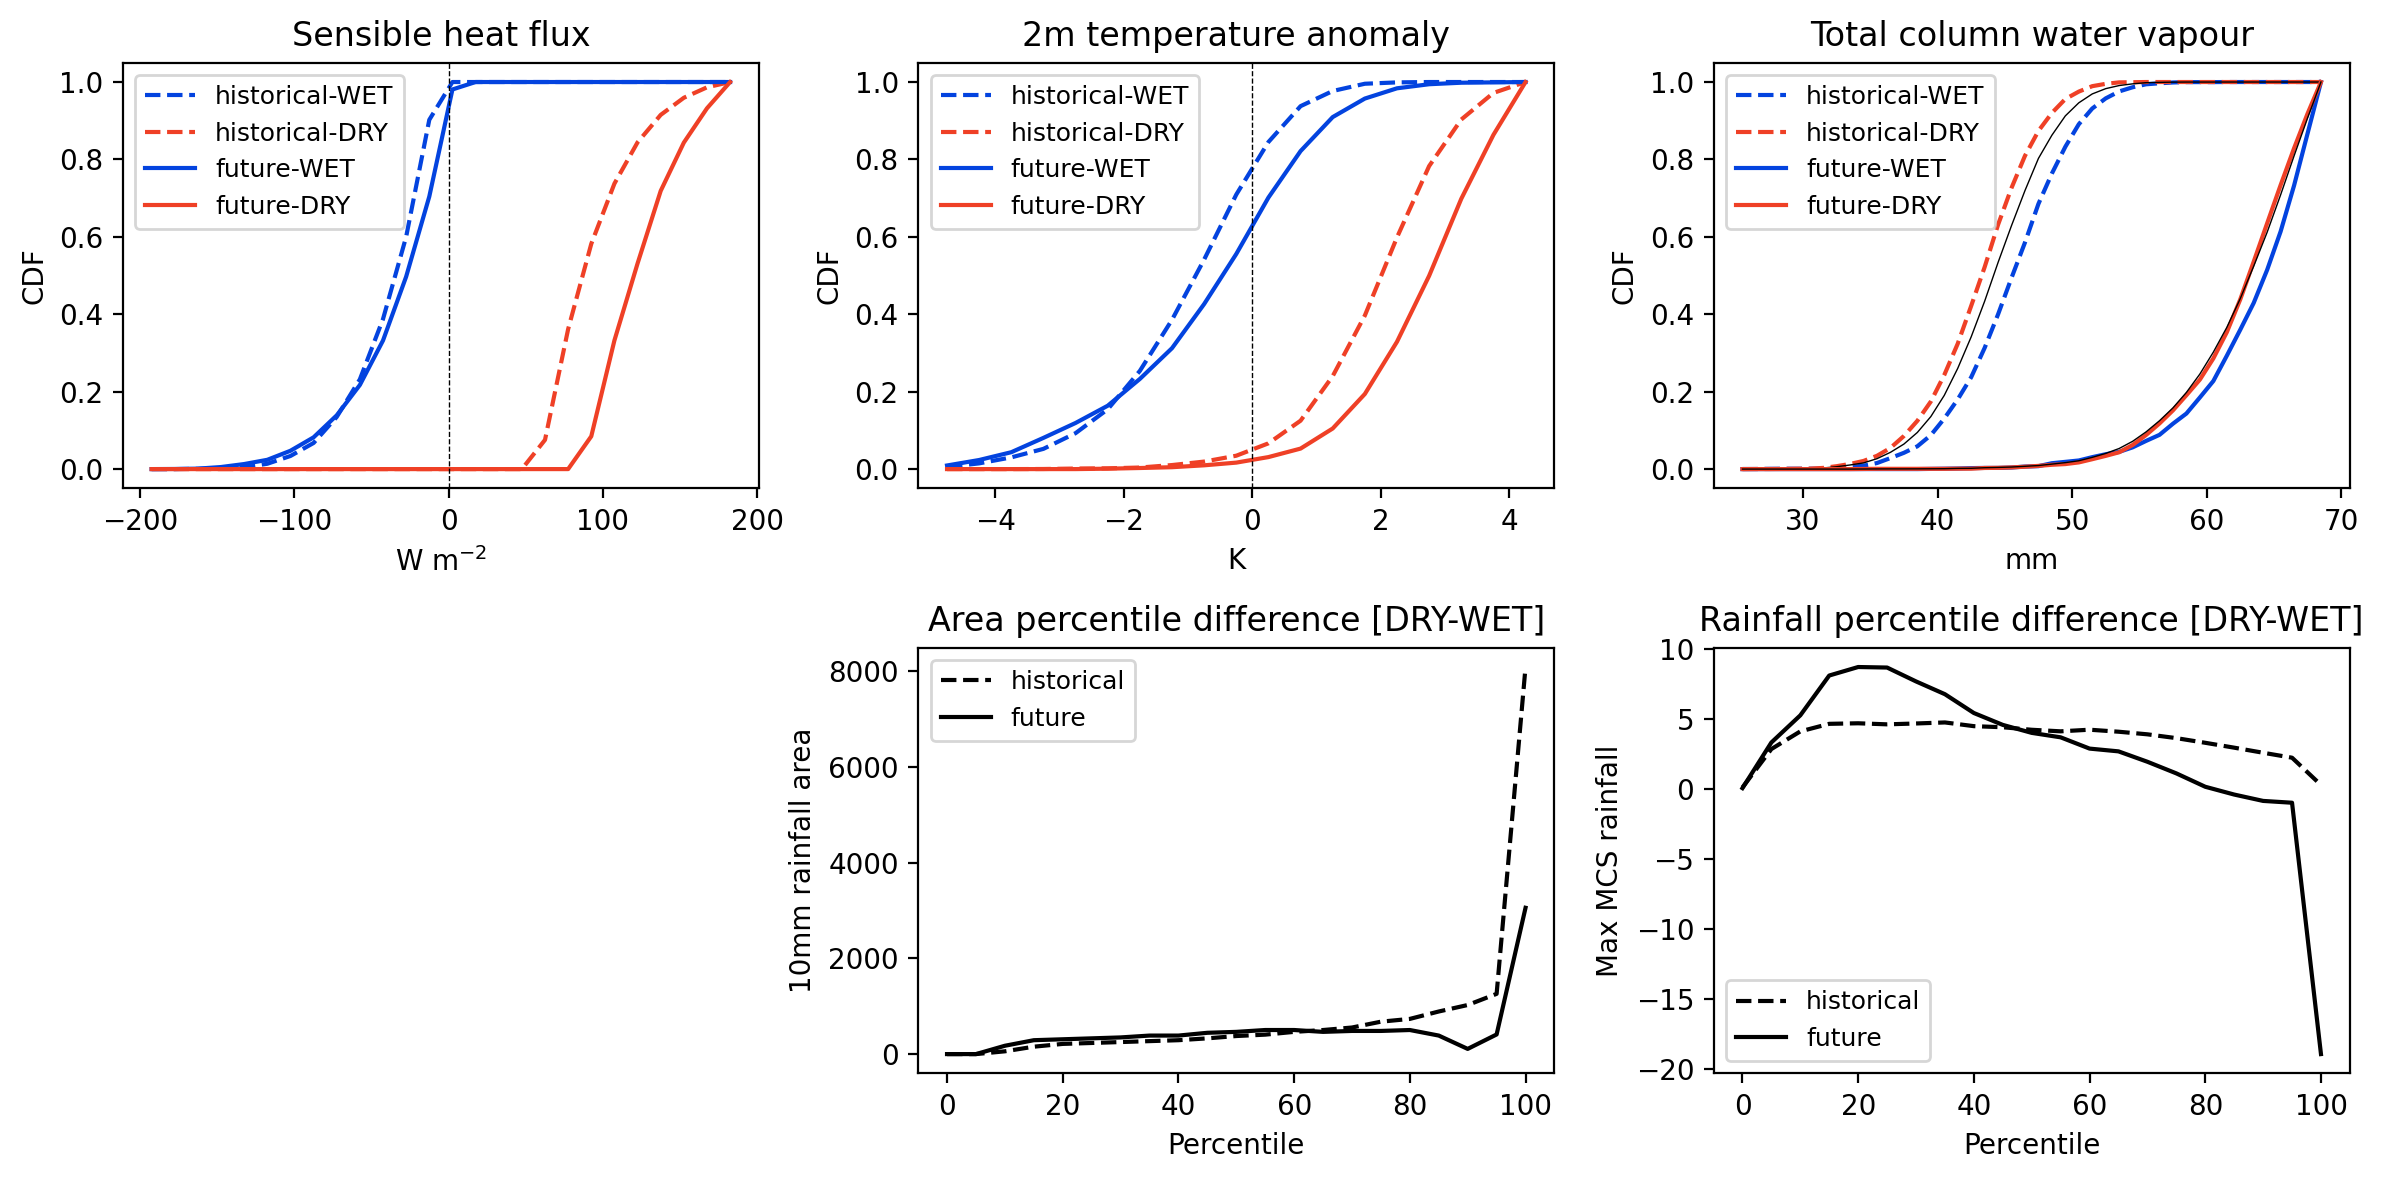

In [269]:
f = plt.figure(figsize=(12,6), dpi=200)



ax1 = f.add_subplot(231)

var = 'sh_1deg'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]


cp4 = hist2d.basic_1d_binning(low, np.arange(-200, 200,15))
cp4f = hist2d.basic_1d_binning(high, np.arange(-200, 200,15))
alle = hist2d.basic_1d_binning(alls, np.arange(-200, 200,15))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(-200, 200,15))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(-200, 200,15))
falle = hist2d.basic_1d_binning(falls, np.arange(-200, 200,15))



bins=cp4['xbins']

cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

stat, pval = stats.mannwhitneyu(low, flow, nan_policy='omit')
print('t2 wet', stat,pval)
stat, pval = stats.mannwhitneyu(high, fhigh, nan_policy='omit')
print('t2 dry', stat,pval)

plt.plot(bins, cumlow, color='xkcd:blue', label='historical-WET', linestyle='dashed')
plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')
#plt.plot(bins, cumall, color='k', label='future' )

plt.plot(bins, fcumlow, color='xkcd:blue', label='future-WET' )
plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
ax1.axvline(0, color='k', linestyle='dashed', linewidth=0.5)
#plt.plot(bins, fcumall, color='grey', label='future' )


plt.ylabel('CDF')
plt.xlabel('W m$^{-2}$')
plt.title('Sensible heat flux')
plt.legend(fontsize=9)
plt.legend(fontsize=9)


ax1 = f.add_subplot(232)

var = 't2_1deg'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]


cp4 = hist2d.basic_1d_binning(low, np.arange(-5, 5,0.5))
cp4f = hist2d.basic_1d_binning(high, np.arange(-5, 5,0.5))
alle = hist2d.basic_1d_binning(alls, np.arange(-5, 5,0.5))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(-5, 5,0.5))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(-5, 5,0.5))
falle = hist2d.basic_1d_binning(falls, np.arange(-5, 5,0.5))



bins=cp4['xbins']

cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

stat, pval = stats.mannwhitneyu(low, flow, nan_policy='omit')
print('t2 wet', stat,pval)
stat, pval = stats.mannwhitneyu(high, fhigh, nan_policy='omit')
print('t2 dry', stat,pval)

plt.plot(bins, cumlow, color='xkcd:blue', label='historical-WET', linestyle='dashed')
plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')
#plt.plot(bins, cumall, color='k', label='future' )

plt.plot(bins, fcumlow, color='xkcd:blue', label='future-WET' )
plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
#plt.plot(bins, fcumall, color='grey', label='future' )


plt.ylabel('CDF')
plt.xlabel('K')
plt.title('2m temperature anomaly')
plt.legend(fontsize=9)
plt.legend(fontsize=9)
ax1.axvline(0, color='k', linestyle='dashed', linewidth=0.5)


ax1 = f.add_subplot(233)

var = 'tcwv_cl'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]


cp4 = hist2d.basic_1d_binning(low, np.arange(25, 70,1))
cp4f = hist2d.basic_1d_binning(high, np.arange(25, 70,1))
alle = hist2d.basic_1d_binning(alls, np.arange(25, 70,1))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(25, 70,1))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(25, 70,1))
falle = hist2d.basic_1d_binning(falls, np.arange(25, 70,1))

bins=cp4['xbins']

cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

plt.plot(bins, cumlow, color='xkcd:blue', label='historical-WET', linestyle='dashed')
plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')
plt.plot(bins, cumall, color='k', linewidth=0.5)

plt.plot(bins, fcumlow, color='xkcd:blue', label='future-WET' )
plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
plt.plot(bins, fcumall, color='k', linewidth=0.5)


plt.ylabel('CDF')
plt.xlabel('mm')
plt.title('Total column water vapour')
plt.legend(fontsize=9)
plt.legend(fontsize=9)


ax = f.add_subplot(235)

var = 'area_10mm'
low = lahist[var][histposlow]*(4.4*4.4)
high = lahist[var][histposhigh]*(4.4*4.4)
alls = lahist[var]*(4.4*4.4)

flow = lafut[var][futposlow]*(4.4*4.4)
fhigh = lafut[var][futposhigh]*(4.4*4.4)
falls = lafut[var]*(4.4*4.4)


cp4 = hist2d.basic_1d_binning(low, np.arange(1, 10000,250))
cp4f = hist2d.basic_1d_binning(high, np.arange(1, 10000,250))
alle = hist2d.basic_1d_binning(alls, np.arange(1, 10000,250))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(1, 10000,250))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(1, 10000,250))
falle = hist2d.basic_1d_binning(falls, np.arange(1, 10000,250))


bins=cp4['xbins']

cumlow = np.percentile(low, np.arange(0,101,5))
cumhigh = np.percentile(high, np.arange(0,101,5))
cumall = np.percentile(alls, np.arange(0,101,5))

fcumlow = np.percentile(flow, np.arange(0,101,5))
fcumhigh = np.percentile(fhigh, np.arange(0,101,5))
fcumall =  np.percentile(falls, np.arange(0,101,5))


plt.plot(np.arange(0,101,5), cumhigh-cumlow, color='k', label='historical', linestyle='dashed')
#plt.plot(np.arange(0,101,5), cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')


plt.plot(np.arange(0,101,5), fcumhigh-fcumlow, color='k', label='future' )
#plt.plot(np.arange(0,101,5), fcumhigh, color='xkcd:tomato', label='future-DRY' )

plt.ylabel('10mm rainfall area')
plt.xlabel('Percentile')
plt.title('Area percentile difference [DRY-WET]')

plt.legend(fontsize=9)



ax1 = f.add_subplot(236)

var = 'pmax'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]


# cp4 = hist2d.basic_1d_binning(low, np.arange(1, 75,1))
# cp4f = hist2d.basic_1d_binning(high, np.arange(1, 75,1))
# alle = hist2d.basic_1d_binning(alls, np.arange(1, 75,1))

# fcp4 = hist2d.basic_1d_binning(flow, np.arange(1, 75,1))
# fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(1, 75,1))
# falle = hist2d.basic_1d_binning(falls, np.arange(1, 75,1))



bins=cp4['xbins']

cumlow = np.percentile(low, np.arange(0,101,5))
cumhigh = np.percentile(high, np.arange(0,101,5))
cumall = np.percentile(alls, np.arange(0,101,5))

fcumlow = np.percentile(flow, np.arange(0,101,5))
fcumhigh = np.percentile(fhigh, np.arange(0,101,5))
fcumall =  np.percentile(falls, np.arange(0,101,5))

stat, pval = stats.mannwhitneyu(low, flow, nan_policy='omit')
print('t2 wet', stat,pval)
stat, pval = stats.mannwhitneyu(high, fhigh, nan_policy='omit')
print('t2 dry', stat,pval)

plt.plot(np.arange(0,101,5), cumhigh-cumlow, color='k', label='historical', linestyle='dashed')
#plt.plot(np.arange(0,101,5), cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')


plt.plot(np.arange(0,101,5), fcumhigh-fcumlow, color='k', label='future' )
#plt.plot(np.arange(0,101,5), fcumhigh, color='xkcd:tomato', label='future-DRY' )
# plt.plot(bins, fcumall, color='k', linewidth=0.5)
# plt.plot(bins, cumall, color='k', label='all cases', linewidth=0.5)

print('allcase difference', np.nanmean(falls)-np.nanmean(alls))
print('drycase difference', np.nanmean(fhigh)-np.nanmean(high))

print('allcase difference rel to hist', (np.nanmean(falls)-np.nanmean(alls))/np.nanmean(alls))
print('drycase difference rel to hist', (np.nanmean(fhigh)-np.nanmean(high))/np.nanmean(high))

plt.ylabel('Max MCS rainfall')
plt.xlabel('Percentile')
plt.title('Rainfall percentile difference [DRY-WET]')
plt.legend(fontsize=9)
plt.legend(fontsize=9)

plt.tight_layout()
#f.savefig(cnst.network_data + 'figs/LMCS/CP4_PNASstudy/SHsplit_variable_distributions_100km-Box.jpg')

In [22]:
import scipy.stats as stats
from scipy.stats import gaussian_kde, linregress
def calc_density(v1,v2):

    xy = np.vstack([v1, v2])

    z = gaussian_kde(xy)(xy)

    return z / (z.max() - z.min())

# cp4s = [lhist[var2], lhist[var]] 
# finites = np.isfinite(cp4s[0])&np.isfinite(cp4s[1])
# cp4s = [(cp4s[0])[finites],(cp4s[1])[finites]]
# r = stats.pearsonr(cp4s[0], cp4s[1])
# density = calc_density(cp4s[0], cp4s[1])
# plt.scatter(cp4s[0], cp4s[1], c=density, cmap='viridis')

# cp4s = [lfut[var2], lfut[var]] 
# finites = np.isfinite(cp4s[0])&np.isfinite(cp4s[1])
# cp4s = [(cp4s[0])[finites],(cp4s[1])[finites]]
# r = stats.pearsonr(cp4s[0], cp4s[1])
# density = calc_density(cp4s[0], cp4s[1])
# plt.scatter(cp4s[0], cp4s[1], c=density, cmap='inferno', alpha=0.3)

In [23]:
from scipy.stats import binned_statistic
def binning(dic, var1, var2, bins):
    func = lambda y: np.nanmean(y)   #  could also be np.percentile(y, 95) etc.
    #func = lambda y: np.nanpercentile(y, 95)  #  could also be np.percentile(y, 95) etc.
    dat, bin_edges, binnumber = binned_statistic(dic[var1], dic[var2], statistic=func, bins=bins)
    tcbins = bin_edges[0:-1] + (bin_edges[1::]-bin_edges[0:-1])/2
  #  ipdb.set_trace()
    pslope, pintercept, pr_value, pp_value, pstd_err = stats.linregress(tcbins[np.isfinite(dat)], dat[np.isfinite(dat)])

    return dat, tcbins, pslope, pintercept, pp_value

In [24]:
len(lahist['lsRain_1deg'])

4712

In [106]:
print(list(lafut.keys()))

['tcwv_0.25deg', 'sh_0.25deg', 'lh_0.25deg', 't2_0.25deg', 'q2_0.25deg', 'shear_0.25deg', 'u_mid_0.25deg', 'u_srfc_0.25deg', 'v_mid_0.25deg', 'v_srfc_0.25deg', 'q_mid_0.25deg', 't_mid_0.25deg', 't_srfc_0.25deg', 'q_srfc_0.25deg', 'geoH_srfc_0.25deg', 'lsRain_noon_0.25deg', 'lwout_noon_0.25deg', 'SM_0.25deg', 'lw_net_0.25deg', 'sw_in_0.25deg', 'sw_net_0.25deg', 'u10_0.25deg', 'v10_0.25deg', 'tcwv_1deg', 'sh_1deg', 'lh_1deg', 't2_1deg', 'q2_1deg', 'shear_1deg', 'u_mid_1deg', 'u_srfc_1deg', 'v_mid_1deg', 'v_srfc_1deg', 'q_mid_1deg', 't_mid_1deg', 't_srfc_1deg', 'q_srfc_1deg', 'geoH_srfc_1deg', 'lsRain_noon_1deg', 'lwout_noon_1deg', 'SM_1deg', 'lw_net_1deg', 'sw_in_1deg', 'sw_net_1deg', 'u10_1deg', 'v10_1deg', 'tcwv_2deg', 'sh_2deg', 'lh_2deg', 't2_2deg', 'q2_2deg', 'shear_2deg', 'u_mid_2deg', 'u_srfc_2deg', 'v_mid_2deg', 'v_srfc_2deg', 'q_mid_2deg', 't_mid_2deg', 't_srfc_2deg', 'q_srfc_2deg', 'geoH_srfc_2deg', 'lsRain_noon_2deg', 'lwout_noon_2deg', 'SM_2deg', 'lw_net_2deg', 'sw_in_2deg', 

In [120]:
np.nanpercentile(lfut['rh'],[1,99])

array([0.34834372, 0.87905012])

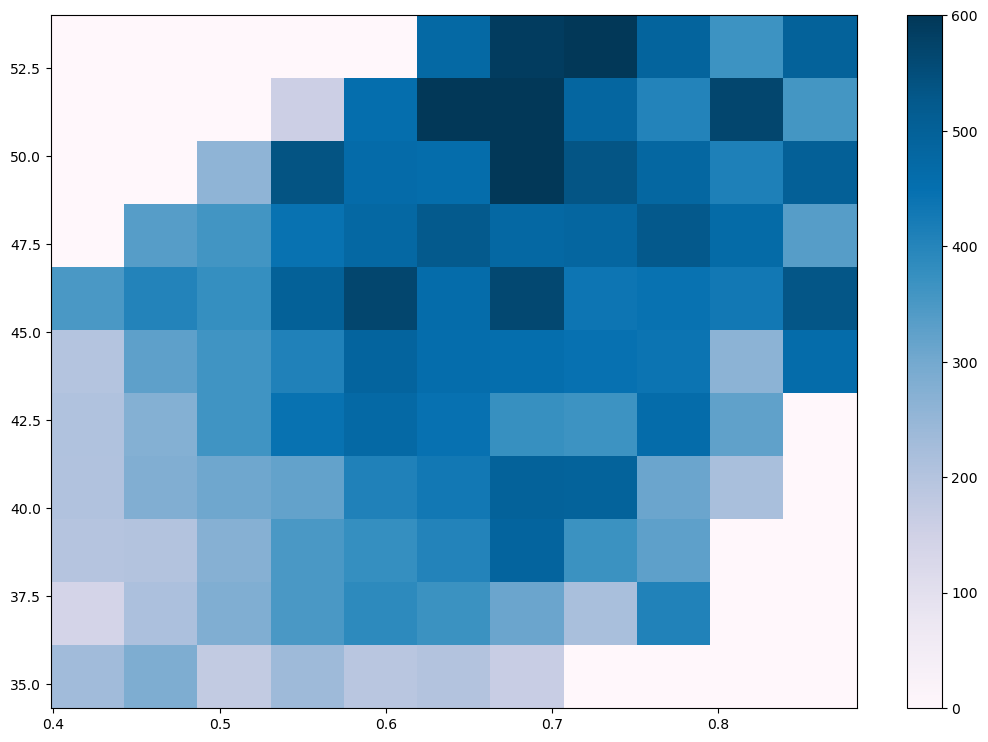

In [135]:
from scipy.stats import binned_statistic_2d
import numpy as np
import matplotlib.pyplot as plt

dat=lhist

y = dat['area-60']
x = dat['tcwv_1deg']
z = dat['rh']

mask = np.isfinite(y) & np.isfinite(x) & np.isfinite(z)
y = y[mask]
x = x[mask]
z = z[mask]

q_perc = np.percentile(x, [1,99])
shear_perc = np.percentile(z, [1,99])
  
tbin = np.linspace(q_perc[0], q_perc[1], 12)  # qbins
sbin = np.linspace(shear_perc[0],shear_perc[1] , 12) # shearbins
plotbins = [sbin,tbin]

## example functions
func1 = lambda y: np.mean(y)                                                  # mean max precip
func2 = lambda y: np.percentile(y,95, interpolation='nearest') # p95 max precip
func3 = lambda y: np.sum(np.isfinite(y))                                  # valid count
func4 = lambda y: np.sum(y>10)                                             # rain threshold frequency

ret = binned_statistic_2d(z, x, y, statistic=func1, bins=plotbins)
count = binned_statistic_2d(z,x, y, statistic=func3, bins=plotbins)
thresh = binned_statistic_2d(z, x, y, statistic=func4, bins=plotbins)
   
to_plot=ret.statistic.T
valid = count.statistic.T
to_plot[valid<5] = 0    # minimum 5 storms


f= plt.figure(figsize=(13,9), dpi=100)
ax = f.add_subplot(111)

mp = plt.pcolormesh(plotbins[0], plotbins[1], to_plot, cmap='PuBu', vmax=600)
plt.colorbar(mp)

PearsonRResult(statistic=0.5822122819328588, pvalue=0.0)
PearsonRResult(statistic=0.5627565329686517, pvalue=0.0)


Text(0.5, 1.0, 'tcwv versus rh')

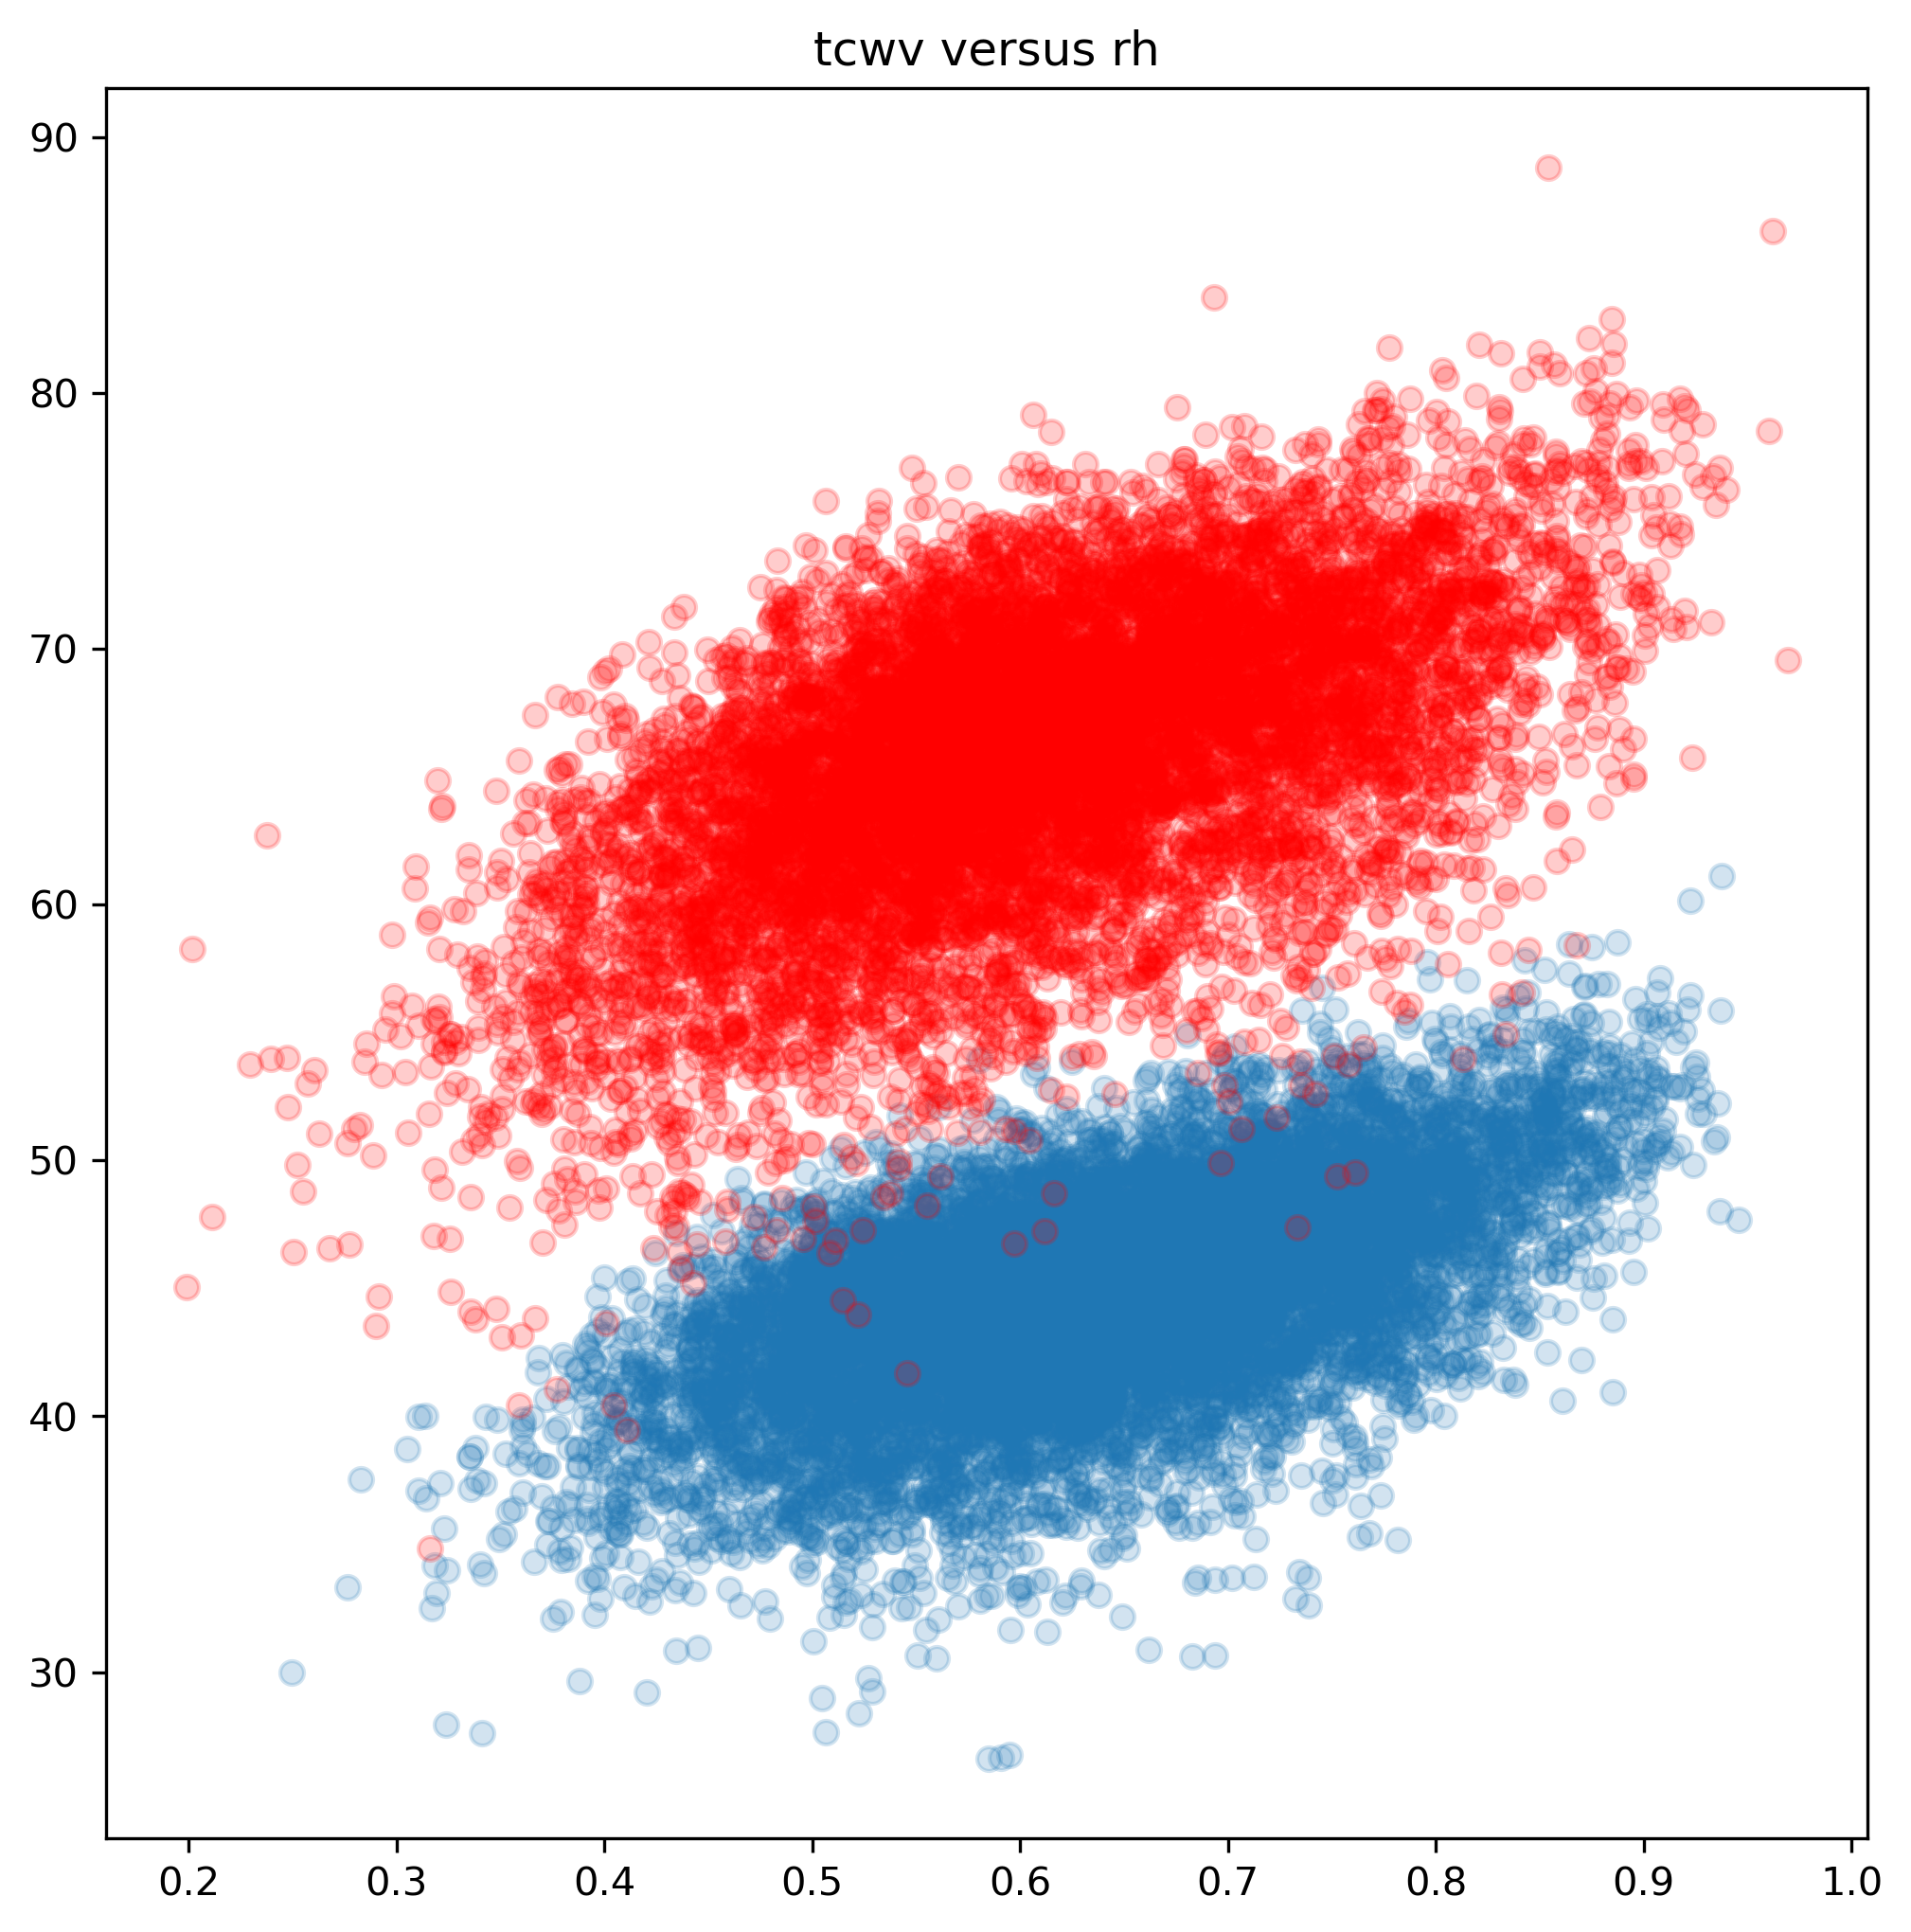

In [142]:
f = plt.figure(figsize=(8,8), dpi=300)
ax = f.add_subplot(111)
a=lhist['tcwv_1deg']
b=lhist['rh']
a = a[np.isfinite(a)&np.isfinite(b)]
b = b[np.isfinite(a)&np.isfinite(b)]
plt.scatter(b,a, alpha=0.2)
print(stats.pearsonr(b, a))
plt.title('tcwv versus rh')

a=lfut['tcwv_1deg']
b=lfut['rh']
a = a[np.isfinite(a)&np.isfinite(b)]
b = b[np.isfinite(a)&np.isfinite(b)]
plt.scatter(b,a, color='red', alpha=0.2)
print(stats.pearsonr(b, a))
plt.title('tcwv versus rh')

pmax
sh_1deg
tcwv_1deg
pmax
sh_1deg
tcwv_1deg


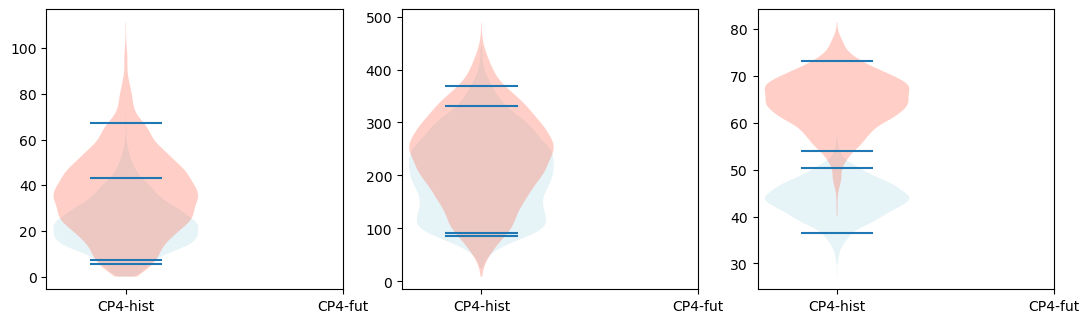

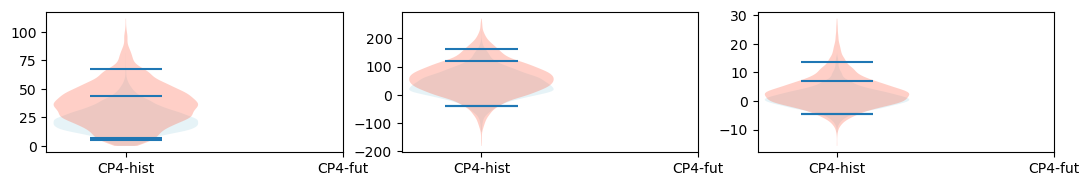

In [28]:
f= plt.figure(figsize=(13,8), dpi=100)
for idx, v in enumerate(['pmax', 'sh_1deg', 'tcwv_1deg']):

    dat1=lhist[v].dropna()
    dat2 = lfut[v].dropna()
    
    data = [dat1, dat2]
    print(v)
    
   # ipdb.set_trace()

    labels = ['CP4-hist', 'CP4-fut']
    
    bpos = np.linspace(0.25,1,len(labels))

    ax = f.add_subplot(2,3,idx+1)
    parts = ax.violinplot(data, positions=[0.25,0.25], showmeans=False, showextrema=False, quantiles=[[0.05,0.95], [0.05,0.95]]) # positions=bpos, whis=[10,90], patch_artist=True, widths=0.1, sym='.', medianprops=dict(color='k'), flierprops=dict(markersize=1)#
    
    (parts['bodies'][0]).set_facecolor('lightblue')
    (parts['bodies'][1]).set_facecolor('tomato')

    (parts['cquantiles']).set_facecolor('k')
    #(parts['cquantiles'][1]).set_facecolor('red')
    
    ax.set_xticks([0.25,1], labels=labels)
    
f= plt.figure(figsize=(13,4), dpi=100)
for idx, v in enumerate(['pmax', 'sh_1deg', 'tcwv_1deg']):

    dat1=lahist[v].dropna()
    dat2 = lafut[v].dropna()
    
    data = [dat1, dat2]
    print(v)
    
   # ipdb.set_trace()

    labels = ['CP4-hist', 'CP4-fut']
    
    bpos = np.linspace(0.25,1,len(labels))

    ax = f.add_subplot(2,3,idx+4)
    parts = ax.violinplot(data, positions=[0.25,0.25], showmeans=False, showextrema=False, quantiles=[[0.05,0.95], [0.05,0.95]]) # positions=bpos, whis=[10,90], patch_artist=True, widths=0.1, sym='.', medianprops=dict(color='k'), flierprops=dict(markersize=1)#
    
    (parts['bodies'][0]).set_facecolor('lightblue')
    (parts['bodies'][1]).set_facecolor('tomato')

    (parts['cquantiles']).set_facecolor('k')
    #(parts['cquantiles'][1]).set_facecolor('red')
    
    ax.set_xticks([0.25,1], labels=labels)

q_srfc_1deg 0.0047947521551475105 0.00011161899150451474
tcwv_1deg 20.65089142556816 1.5117814815260424
t_srfc_1deg 5.919227255463966 0.4260644757207303
lh_1deg -50.994261711244434 -29.622043333711446
sh_1deg 31.632383372640703 20.06309071353993
theta 6.052555837647674 0.4356614332313975
theta-e 22.74070863941006 1.099399698188189


<BarContainer object of 7 artists>

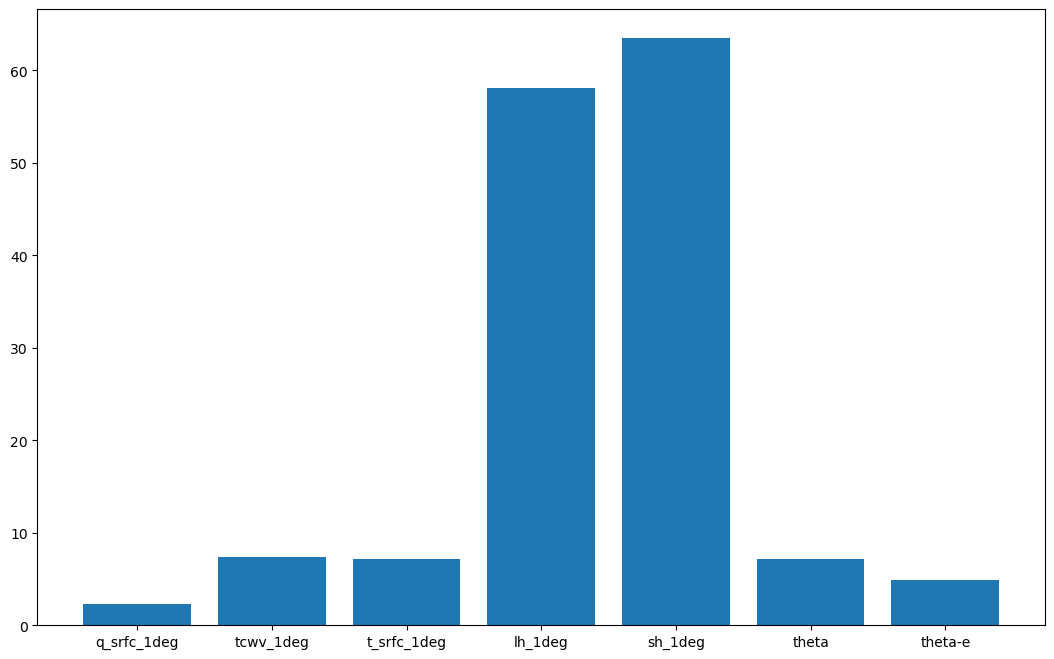

In [270]:
f= plt.figure(figsize=(13,8), dpi=100)
collect = []
varts = ['q_srfc_1deg', 'tcwv_1deg', 't_srfc_1deg', 'lh_1deg', 'sh_1deg', 'theta', 'theta-e']
for idx, v in enumerate(varts):
    efhist = lhist['EF']<0.75
    effut = lfut['EF']<0.75
    climhist=np.nanmean((lhist[v])[efhist].dropna())
    climfut= np.nanmean((lfut[v])[effut].dropna())
    
    anohist = np.mean(lahist[v].dropna())
    anofut= np.mean(lafut[v].dropna())
    
    print(v, climfut-climhist, anofut-anohist)
    

    
    
    anomcont = (anofut-anohist)/(climfut-climhist)*100
    
    collect.append(anomcont)
#ipdb.set_trace()

plt.bar(np.arange(len(varts)), height=collect, tick_label=varts)